## Import

In [1]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV 

from ML.utils.utils import gaussian

import pandas as pd

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler

In [3]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_B/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_B/fine_tuned_models/"
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

In [4]:
override = True
use_preds = False
save = True
show = True

In [5]:
def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

## Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'metallicity', 'star_mass'], 
                               y_cols=['log_Teff', 'log_g', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the log_Teff parameter : 3.344668191350628 - 4.634489491902143
Median value in train data for the log_Teff parameter: 3.8641118622993966
Mean value in train data for the log_Teff parameter: 3.9345581069095505

Range in train data for the log_g parameter : -1.0828963170617296 - 5.433094523832443
Median value in train data for the log_g parameter: 3.9484790508590737
Mean value in train data for the log_g parameter: 3.548006174763417

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the log_Teff parameter : 3.344711147414537 - 4.633956017110521
Median value in test data for the log_Teff parameter: 3.865317881638998
Mean value in test data for the log_Teff parameter: 3.9346904482232112

Range in test data for the log_g p

# Faire le fine-tuning avec mass_smaller_14 et random_forest, KNN, decision tree

## Fine-tuning

### Random forest

In [9]:
tag = "scale_quantile_14"

#### Tuning the n_estimators and criterion parameters

In [11]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [50, 100, 200, 300, 400, 500, 600]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 14 candidates, totalling 140 fits
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.4s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.2s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.7s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.0s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.1s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.1s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.3s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.0s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   5.8s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.0s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  12.1s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,6.127439,0.239951,0.143971,0.006762,squared_error,50,"{'criterion': 'squared_error', 'n_estimators':...",-0.288481,-0.285859,-0.287004,-0.282914,-0.286447,-0.280526,-0.277455,-0.278856,-0.286783,-0.289124,-0.284345,0.003923,14,-0.085298,-0.084188,-0.084802,-0.083111,-0.083751,-0.082635,-0.081428,-0.080976,-0.085062,-0.085981,-0.083723,0.001585,14
1,11.792084,0.109919,0.274414,0.010009,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.287904,-0.286043,-0.286291,-0.282419,-0.286343,-0.279383,-0.277154,-0.278291,-0.285692,-0.288005,-0.283752,0.003895,13,-0.085068,-0.084238,-0.084559,-0.083085,-0.083947,-0.082385,-0.081138,-0.081013,-0.084830,-0.085654,-0.083592,0.001544,13
2,23.184146,0.585870,0.695456,0.495849,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.287219,-0.285739,-0.286171,-0.282363,-0.285509,-0.279002,-0.277631,-0.278024,-0.285300,-0.287803,-0.283476,0.003711,11,-0.084844,-0.084146,-0.084447,-0.083103,-0.083690,-0.082287,-0.081309,-0.080934,-0.084628,-0.085617,-0.083500,0.001481,11
3,34.519052,0.511208,1.056191,0.687166,squared_error,300,"{'criterion': 'squared_error', 'n_estimators':...",-0.286886,-0.285648,-0.285819,-0.282461,-0.285820,-0.278941,-0.277240,-0.277728,-0.285603,-0.287853,-0.283400,0.003801,10,-0.084757,-0.084088,-0.084449,-0.083097,-0.083760,-0.082240,-0.081199,-0.080896,-0.084726,-0.085603,-0.083482,0.001505,9
4,48.421111,0.884767,29.689518,1.965934,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.287429,-0.286197,-0.285952,-0.282291,-0.285515,-0.278995,-0.277036,-0.277968,-0.285624,-0.287845,-0.283485,0.003877,12,-0.084923,-0.084255,-0.084451,-0.083079,-0.083708,-0.082253,-0.081118,-0.080947,-0.084738,-0.085627,-0.083510,0.001534,12
5,60.995235,0.670807,39.474422,12.303953,squared_error,500,"{'criterion': 'squared_error', 'n_estimators':...",-0.287022,-0.285886,-0.285956,-0.282463,-0.285297,-0.278575,-0.277364,-0.277924,-0.285556,-0.287639,-0.283368,0.003777,8,-0.084848,-0.084153,-0.084454,-0.083097,-0.083662,-0.082221,-0.081219,-0.080873,-0.084710,-0.085601,-0.083484,0.001515,10
6,72.694510,0.533125,46.117796,8.862630,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.287172,-0.285618,-0.285976,-0.282390,-0.285664,-0.278456,-0.277214,-0.277709,-0.285702,-0.288081,-0.283398,0.003927,9,-0.084847,-0.084048,-0.084434,-0.083099,-0.083765,-0.082109,-0.081186,-0.080833,-0.084774,-0.085666,-0.083476,0.001547,8
7,5.490134,0.309762,0.146294,0.007094,friedman_mse,50,"{'criterion': 'friedman_mse', 'n_estimators': 50}",-0.286050,-0.285064,-0.285604,-0.281843,-0.284739,-0.278330,-0.277804,-0.277617,-0.285248,-0.286961,-0.282926,0.003510,7,-0.084666,-0.083836,-0.084588,-0.082923,-0.083820,-0.082095,-0.081282,-0.080872,-0.084878,-0.085429,-0.083439,0.001499,7
8,10.701908,0.162367,0.281697,0.008486,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",

Best parameters {'criterion': 'friedman_mse', 'n_estimators': 500}
Best score -0.2819439325491946


#### Tuning the max_depth, min_samples_split and min_samples_leaf parameters

In [10]:
cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100, # results with 600 are better but take more time, doing gridsearchcv with 100 is comparable to 600
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.6s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.7s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.5s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  11.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=   9.8s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,11.154422,0.199613,0.280719,0.016989,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.285526,-0.284317,-0.284393,-0.280876,-0.284552,-0.277914,-0.276356,-0.276403,-0.285531,-0.286691,-0.282256,0.003808,25,-0.084563,-0.083672,-0.084128,-0.082799,-0.083605,-0.082129,-0.081025,-0.080626,-0.084810,-0.085371,-0.083273,0.001517,25
1,9.506609,0.117069,0.195488,0.003798,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.264184,-0.261765,-0.262243,-0.258832,-0.263109,-0.257332,-0.255383,-0.255647,-0.262804,-0.264090,-0.260539,0.003252,23,-0.080979,-0.080033,-0.080525,-0.079291,-0.079915,-0.078949,-0.077657,-0.077557,-0.081076,-0.081462,-0.079744,0.001302,22
2,8.991166,0.195989,0.165057,0.006982,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.253921,-0.252342,-0.252321,-0.247920,-0.253473,-0.246883,-0.246413,-0.246373,-0.253143,-0.253959,-0.250675,0.003152,19,-0.080733,-0.080167,-0.080447,-0.078856,-0.079793,-0.078901,-0.077942,-0.077440,-0.081160,-0.081380,-0.079682,0.001279,19
3,9.011894,0.108729,0.181930,0.008077,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.247213,-0.246676,-0.245979,-0.242843,-0.248519,-0.241510,-0.240839,-0.241419,-0.248107,-0.247834,-0.245094,0.002926,15,-0.078270,-0.077985,-0.078171,-0.076899,-0.077663,-0.076579,-0.075805,-0.075584,-0.078950,-0.078899,-0.077481,0.001145,2
4,8.952536,0.169234,0.182405,0.007185,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.247540,-0.246542,-0.246482,-0.242760,-0.248517,-0.241945,-0.240689,-0.241002,-0.247831,-0.248084,-0.245139,0.002994,16,-0.078386,-0.077998,-0.078294,-0.076865,-0.077617,-0.076677,-0.075713,-0.075485,-0.078947,-0.079074,-0.077506,0.001208,4
5,8.712367,0.119272,0.148564,0.006912,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.242253,-0.242343,-0.241140,-0.237714,-0.243540,-0.237159,-0.236884,-0.236940,-0.242847,-0.242644,-0.240346,0.002658,10,-0.079008,-0.079007,-0.078896,-0.077639,-0.078388,-0.077620,-0.076774,-0.076429,-0.079701,-0.079617,-0.078308,0.001086,8
6,8.716893,0.218367,0.146678,0.006877,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.237020,-0.237417,-0.235681,-0.232476,-0.238093,-0.232219,-0.231996,-0.231794,-0.238365,-0.237405,-0.235247,0.002643,5,-0.079342,-0.079471,-0.079261,-0.077981,-0.078816,-0.078085,-0.077286,-0.076802,-0.080321,-0.079849,-0.078721,0.001085,15
7,8.788361,0.100289,0.145113,0.008007,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.237055,-0.237372,-0.236081,-0.232532,-0.238365,-0.232236,-0.231889,-0.232216,-0.238212,-0.237601,-0.235356,0.002633,9,-0.079354,-0.079412,-0.079395,-0.077948,-0.078852,-0.078153,-0.077262,-0.076990,-0.080265,-0.079921,-0.078755,0.001059,18
8,8.821047,0.224078,0.152358,0.006894,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.236647,-0.236847,-0.235781,-0.232646,-0.237699,-0.231956,-0.232389,-0.

Best parameters {'max_depth': 100, 'min_samples_leaf': 5, 'min_samples_split': 6}
Best score -0.23518562072812532


#### Tuning the max_features and max_leaf_nodes parameters

In [11]:
cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [100, 500, 1000, None]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100,
                                             max_depth=100,
                                             min_samples_leaf=5,
                                             min_samples_split=6
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.4s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.2s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.1s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.1s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.2s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.1s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.3s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.0s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.1s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.1s
[CV] END ..............max_features=sqrt, max_leaf_nodes=500; total time=   3.7s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,3.190729,0.120777,0.055588,0.020445,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.447559,-0.451133,-0.446832,-0.451156,-0.452887,-0.446430,-0.445133,-0.448092,-0.449311,-0.446463,-0.448500,0.002398,12,-0.346085,-0.351713,-0.345532,-0.351722,-0.352516,-0.347107,-0.344795,-0.347871,-0.349945,-0.346554,-0.348384,0.002707,12
1,3.663681,0.040431,0.050390,0.006453,sqrt,500,"{'max_features': 'sqrt', 'max_leaf_nodes': 500}",-0.386122,-0.385669,-0.382411,-0.381333,-0.384452,-0.380220,-0.382671,-0.381721,-0.383278,-0.382745,-0.383062,0.001780,9,-0.285586,-0.284174,-0.283039,-0.281066,-0.284658,-0.282016,-0.284752,-0.282646,-0.283642,-0.282866,-0.283445,0.001311,9
2,3.864295,0.060946,0.063593,0.016912,sqrt,1000,"{'max_features': 'sqrt', 'max_leaf_nodes': 1000}",-0.347368,-0.343438,-0.344851,-0.345581,-0.345105,-0.344134,-0.344182,-0.342740,-0.345102,-0.347310,-0.344981,0.001424,6,-0.247569,-0.242443,-0.244963,-0.245107,-0.245943,-0.246369,-0.246471,-0.244358,-0.244552,-0.246359,-0.245413,0.001372,6
3,5.018131,0.072450,0.162390,0.021225,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.234580,-0.234316,-0.231560,-0.230535,-0.234559,-0.226708,-0.226691,-0.228187,-0.234237,-0.234777,-0.231615,0.003207,1,-0.079078,-0.078842,-0.078729,-0.077955,-0.078425,-0.076739,-0.076662,-0.076209,-0.079384,-0.079320,-0.078134,0.001125,1
4,3.105368,0.057745,0.047321,0.008713,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.448312,-0.453320,-0.451424,-0.443426,-0.445255,-0.449530,-0.444719,-0.444108,-0.450965,-0.444718,-0.447578,0.003385,11,-0.348505,-0.352625,-0.351559,-0.341546,-0.344559,-0.350928,-0.343775,-0.343471,-0.351707,-0.344090,-0.347277,0.003982,11
5,3.623290,0.070623,0.054487,0.007428,log2,500,"{'max_features': 'log2', 'max_leaf_nodes': 500}",-0.380675,-0.381938,-0.383569,-0.382228,-0.382670,-0.381348,-0.382947,-0.382716,-0.382999,-0.387347,-0.382844,0.001704,8,-0.280389,-0.280583,-0.282751,-0.282699,-0.282544,-0.281279,-0.284533,-0.282620,-0.283142,-0.286477,-0.282702,0.001723,8
6,3.872380,0.087382,0.062808,0.013319,log2,1000,"{'max_features': 'log2', 'max_leaf_nodes': 1000}",-0.345420,-0.346851,-0.347327,-0.345114,-0.343970,-0.343743,-0.342927,-0.345169,-0.350604,-0.344608,-0.345573,0.002104,7,-0.246320,-0.246950,-0.248108,-0.245665,-0.243744,-0.245197,-0.244590,-0.246097,-0.251014,-0.244843,-0.246253,0.001978,7
7,5.108879,0.073875,0.158555,0.012204,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.234148,-0.234144,-0.231536,-0.230611,-0.234678,-0.226980,-0.226725,-0.228897,-0.234316,-0.234439,-0.231647,0.003021,2,-0.079150,-0.078901,-0.078911,-0.077998,-0.078383,-0.077246,-0.076508,-0.076440,-0.079318,-0.079564,-0.078242,0.001093,2
8,6.311275,0.112404,0.055762,0.008715,None,100,"{'max_features': None, 'max_leaf_nodes': 100}",-0.425019,-0.424230,-0.421755,-0.424823,-0.424039,-0.424314,-0.423007,-0.421810,-0.426928,-0.425064,-

Best parameters {'max_features': 'sqrt', 'max_leaf_nodes': None}
Best score -0.23161522606343993


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_B/fine_tuned_models/

scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.344668191350628 - 4.634489491902143
  RVE :  0.9876737548290488
  RMSE :  0.033491657369971006
  MAE :  0.007278377398812818
  MedAE :  0.0018613694938345304
  CORR :  0.9938284886566244
  MAX_ER :  0.8250158242143906
  Percentiles : 
    75th percentile :  0.00443112726610817
    90th percentile :  0.010471647405696593
    95th percentile :  0.018780347588700584
    99th percentile :  0.10739973347155779

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.5876557299556575
  RVE :  0.9730446087637086
  RMSE :  0.04039186269891783
  MAE :  0.020571769065897617
  MedAE :  0.007081530465292252
  CORR :  0.986537880882697
  MAX_ER :  0.5725903868499129
  Percentiles : 
    75th percentile :  0.

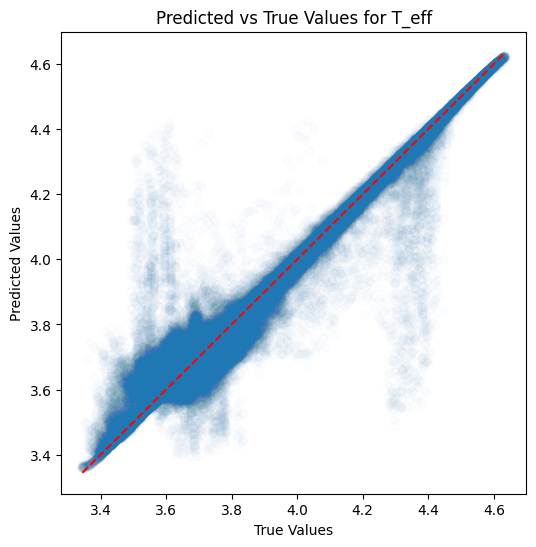

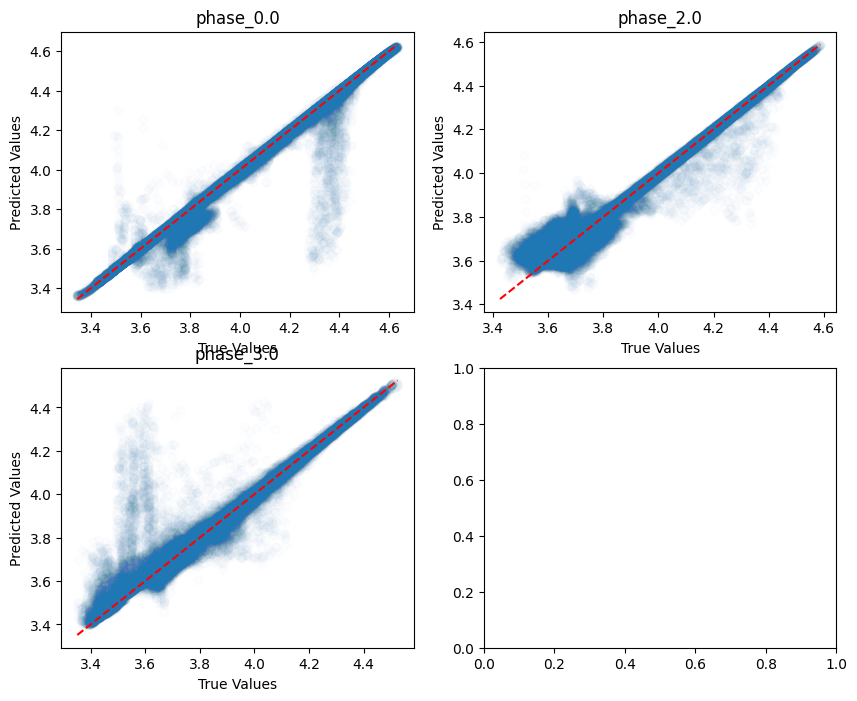

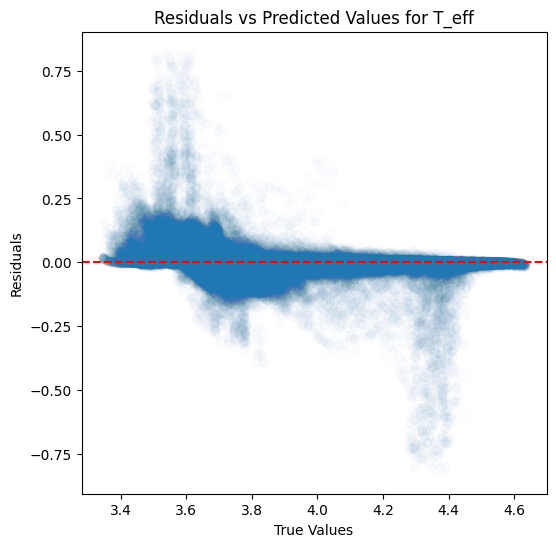

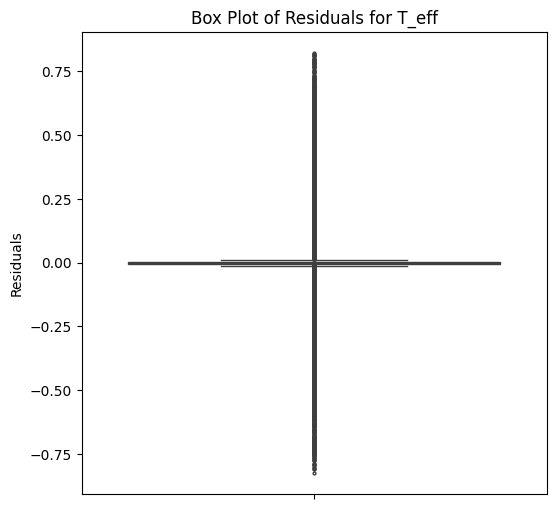

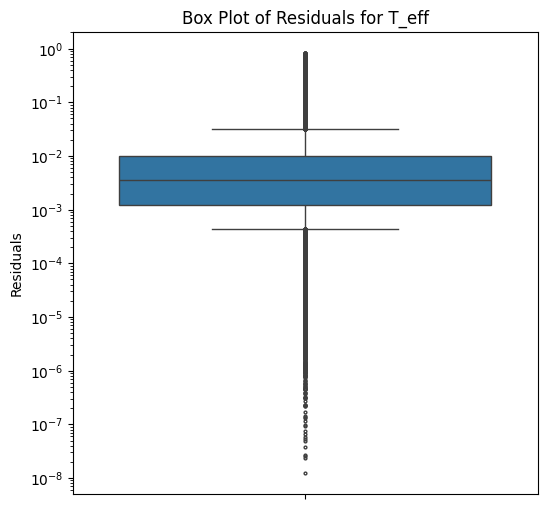

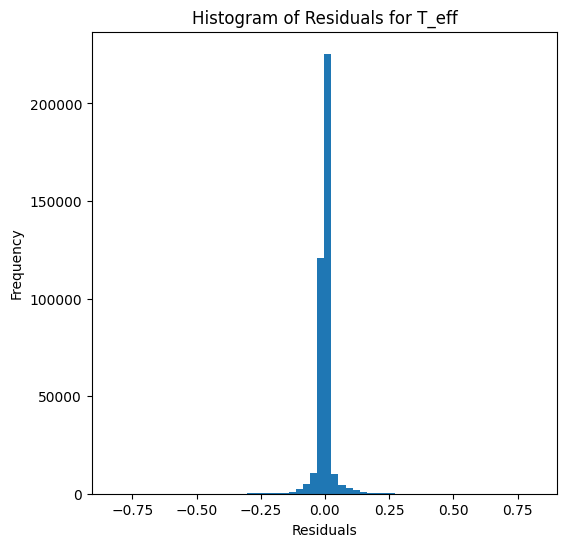

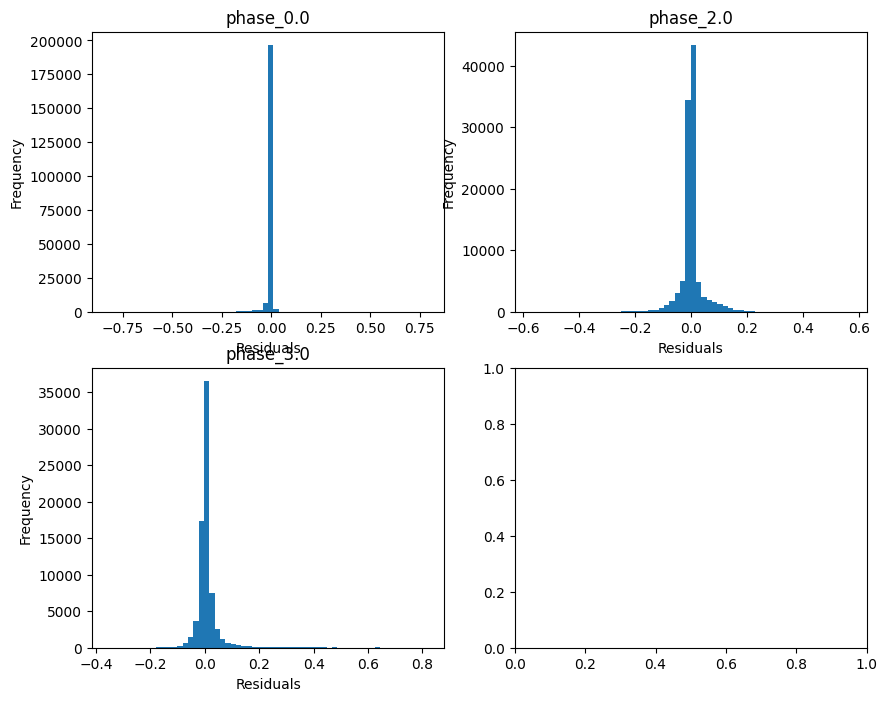

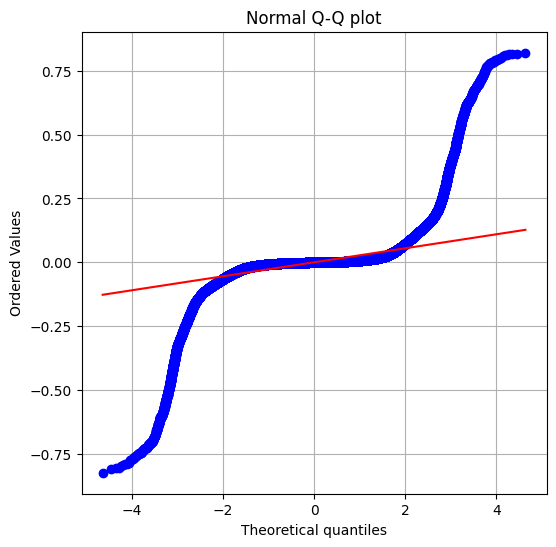

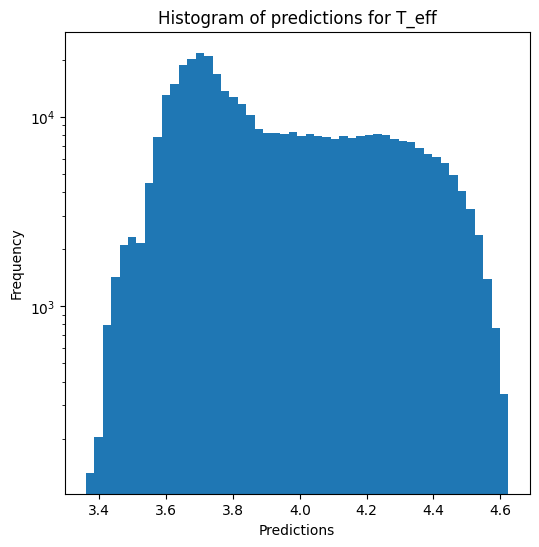

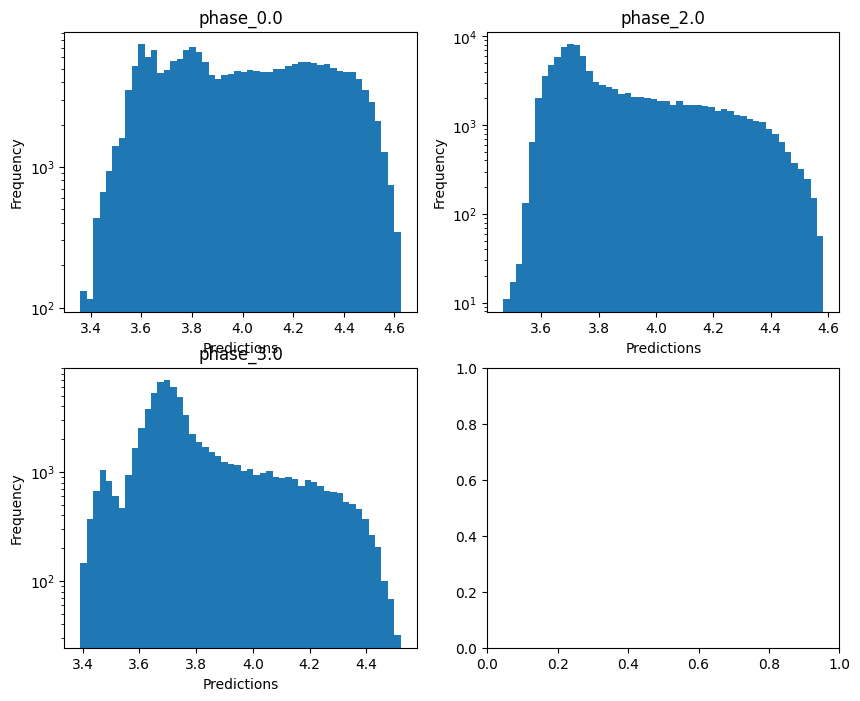


log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.6041675246808076
  RMSE :  0.29157582120868564
  MAE :  0.05726098723870271
  MedAE :  0.00588819826548459
  CORR :  0.8611275668550256
  MAX_ER :  5.181705129284706
  Percentiles : 
    75th percentile :  0.018945842005420488
    90th percentile :  0.05273108937741303
    95th percentile :  0.12018471167837048
    99th percentile :  1.6265163934495133

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.4079093481651865
  RVE :  0.5416527784738017
  RMSE :  0.6288828639433042
  MAE :  0.30058916633812527
  MedAE :  0.03138174033177754
  CORR :  0.7399938105699428
  MAX_ER :  4.083614388209318
  Percentiles : 
    75th percentile :  0.3087539119393454
    90th percentile :  1.1191356663316308
    95th percentile :  1.5774779628608258
    99th percentile :  2.3888446513931267

log_g results for the phase category with

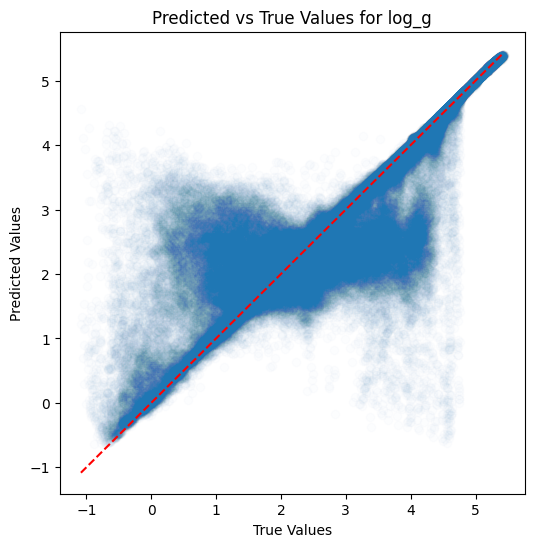

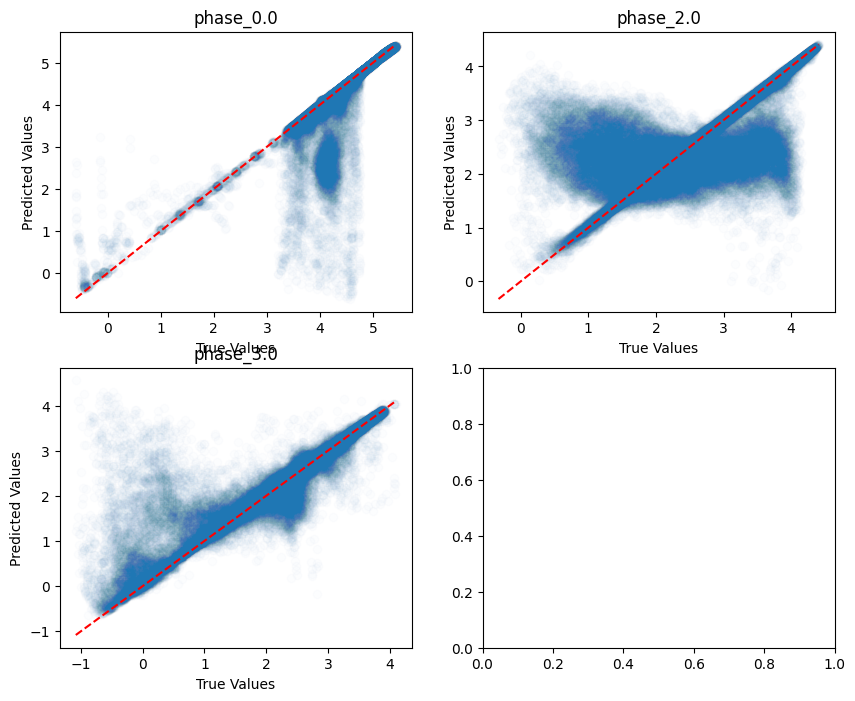

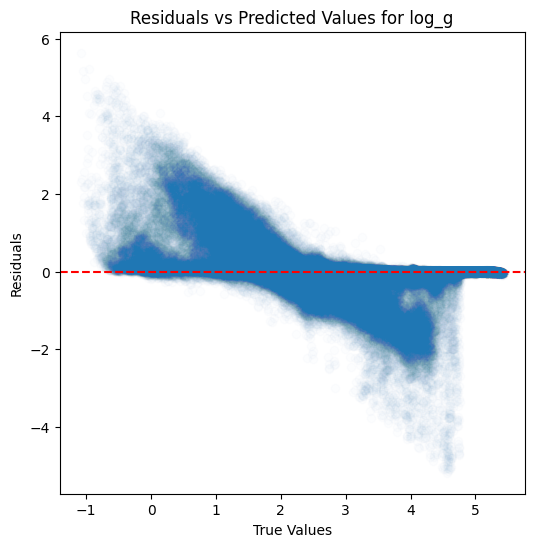

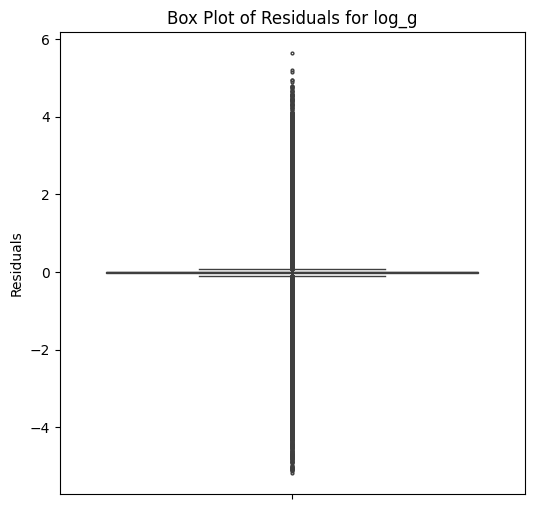

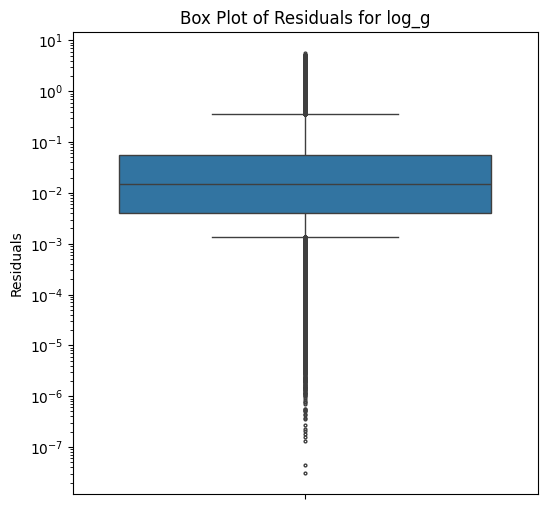

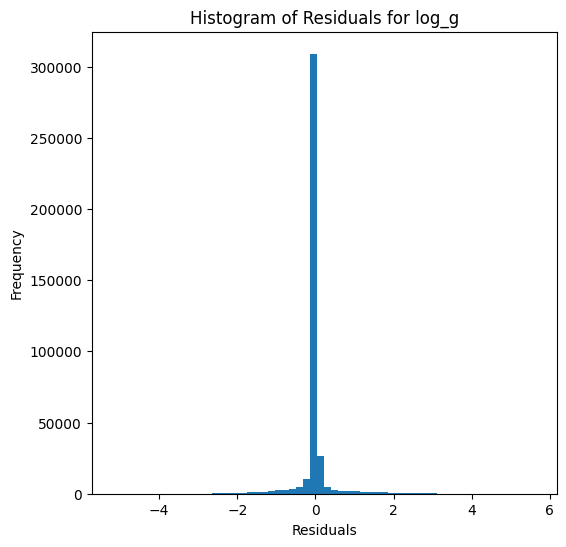

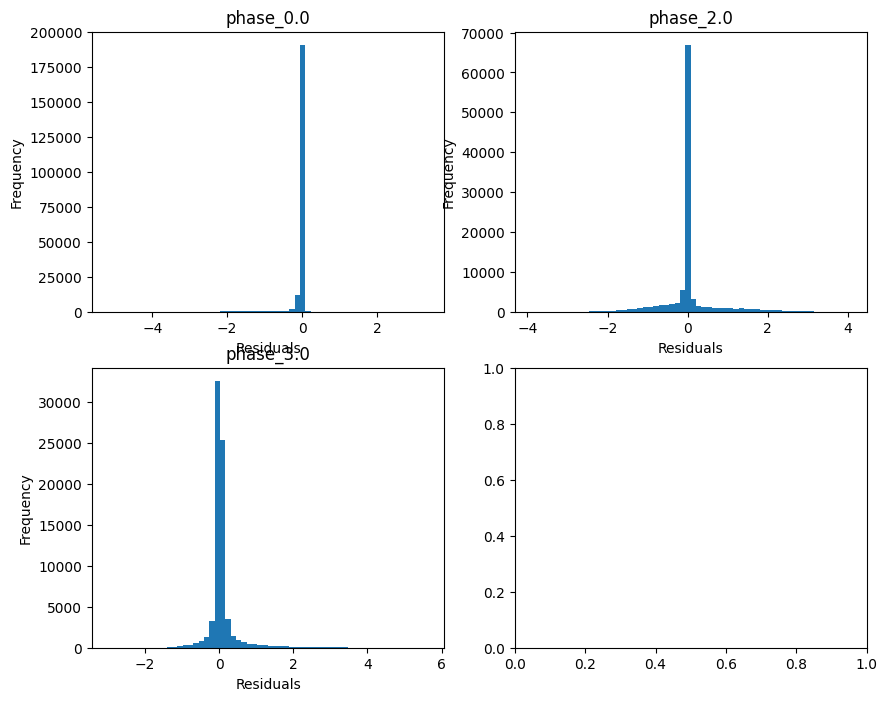

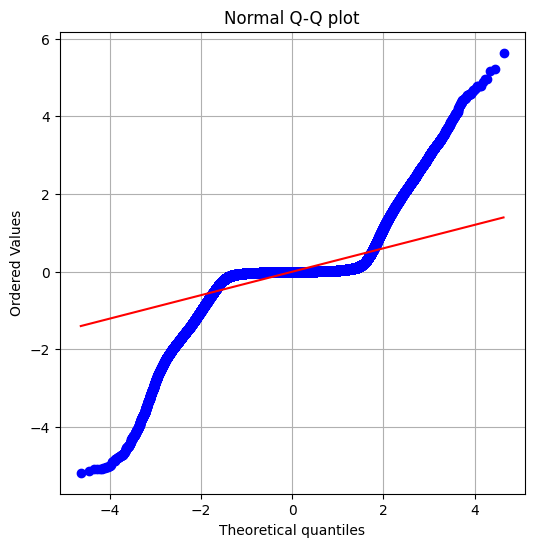

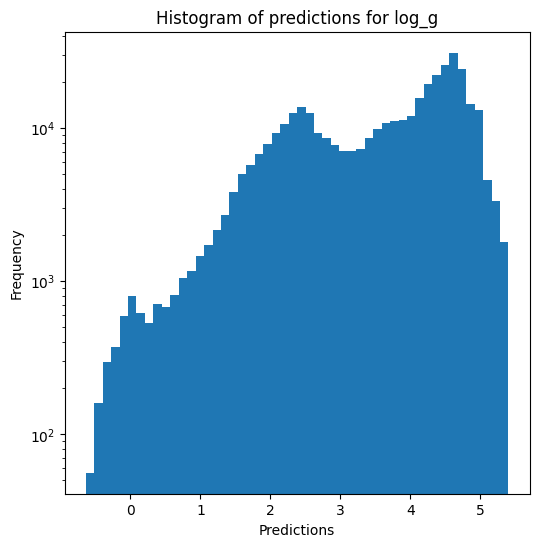

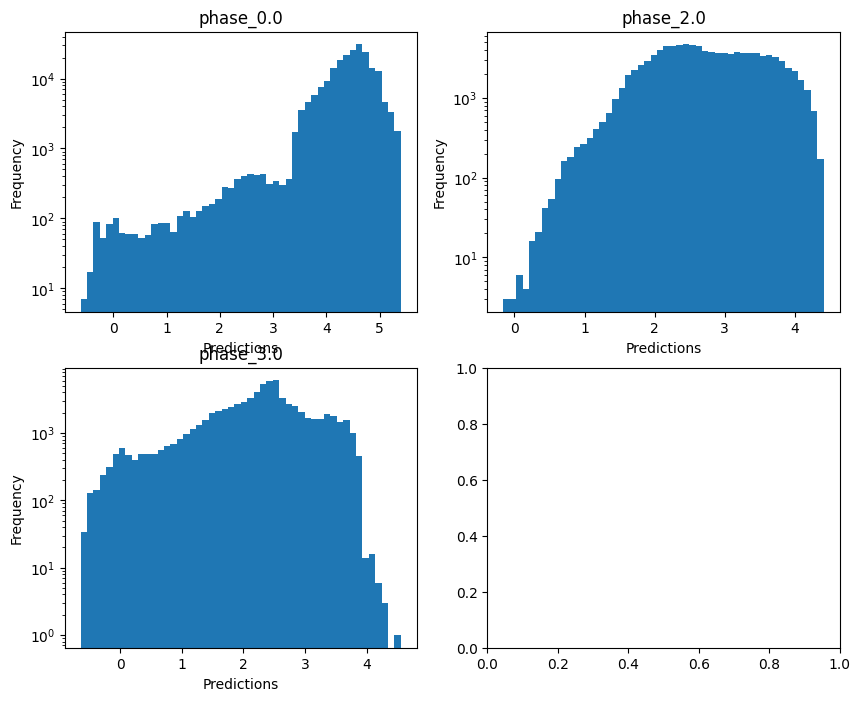

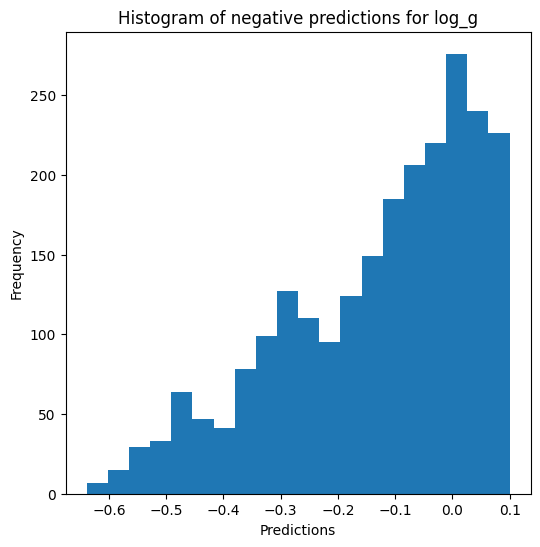


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.8840607282447694
  RMSE :  0.14584696875036485
  MAE :  0.02941997945633306
  MedAE :  0.003893096948309749
  CORR :  0.9479133493281012
  MAX_ER :  2.5922602958085497
  Percentiles : 
    75th percentile :  0.010973729898348106
    90th percentile :  0.027677955565782505
    95th percentile :  0.06034185101669806
    99th percentile :  0.8134077077073815

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.5445738508335876
  RMSE :  0.31443499389273727
  MAE :  0.1502928556672923
  MedAE :  0.015697586044533973
  CORR :  0.745363928203293
  MAX_ER :  2.0416367209424124
  Percentiles : 
    75th percentile :  0.15434455066827552
    90th percentile :  0.559478652475103
    95th percentile :  0.7887183141379795
    99th percentile :  1.194529151575761

radius results for the phase category

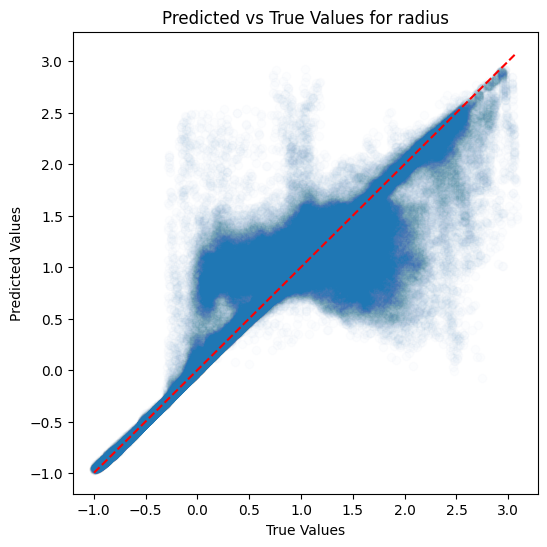

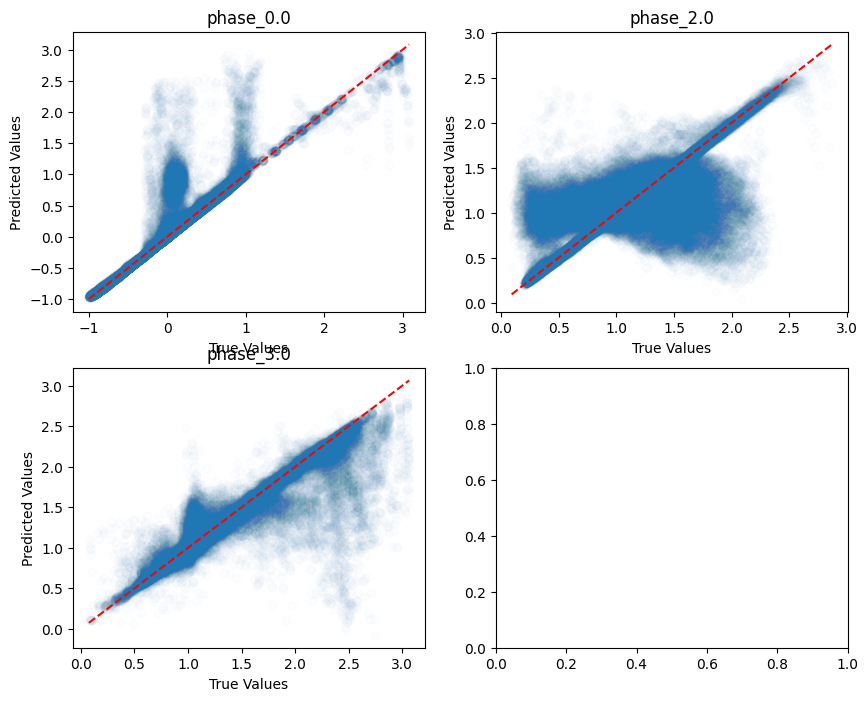

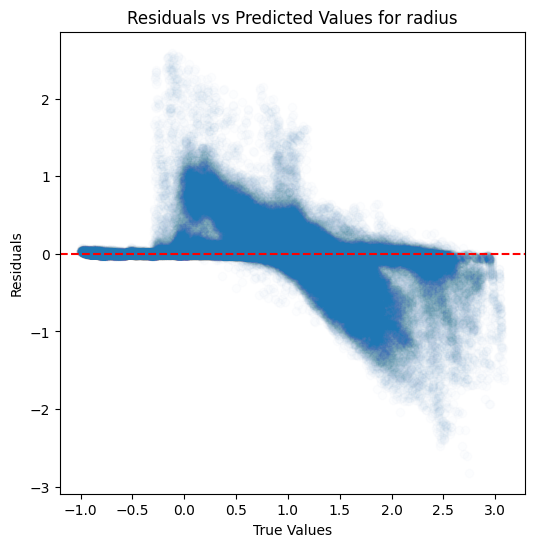

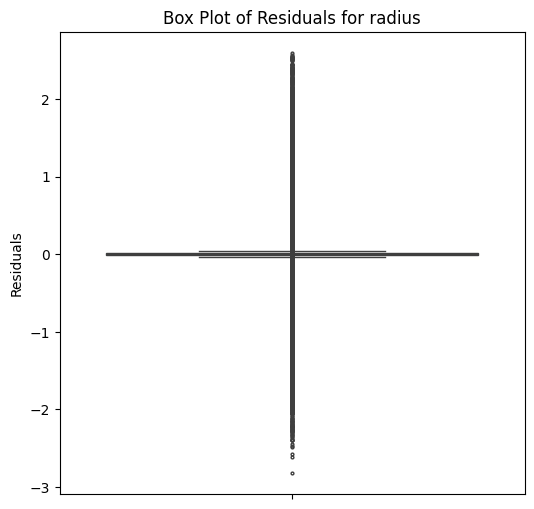

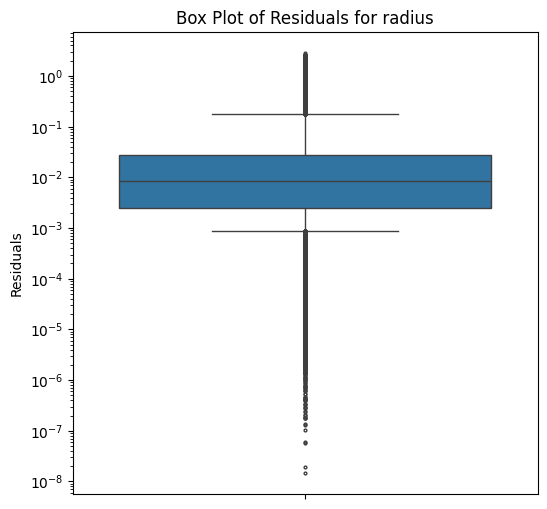

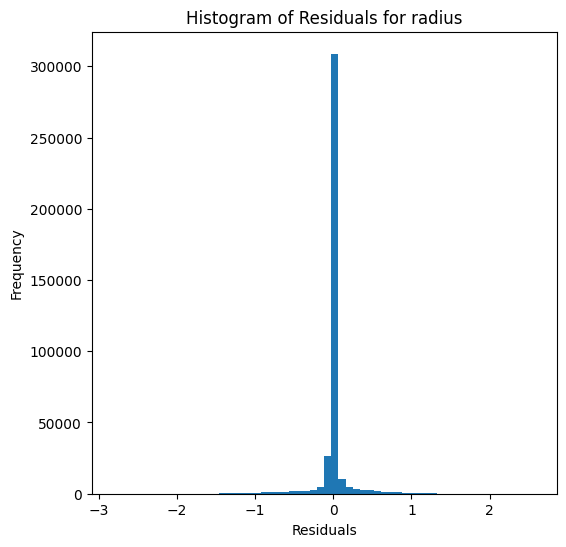

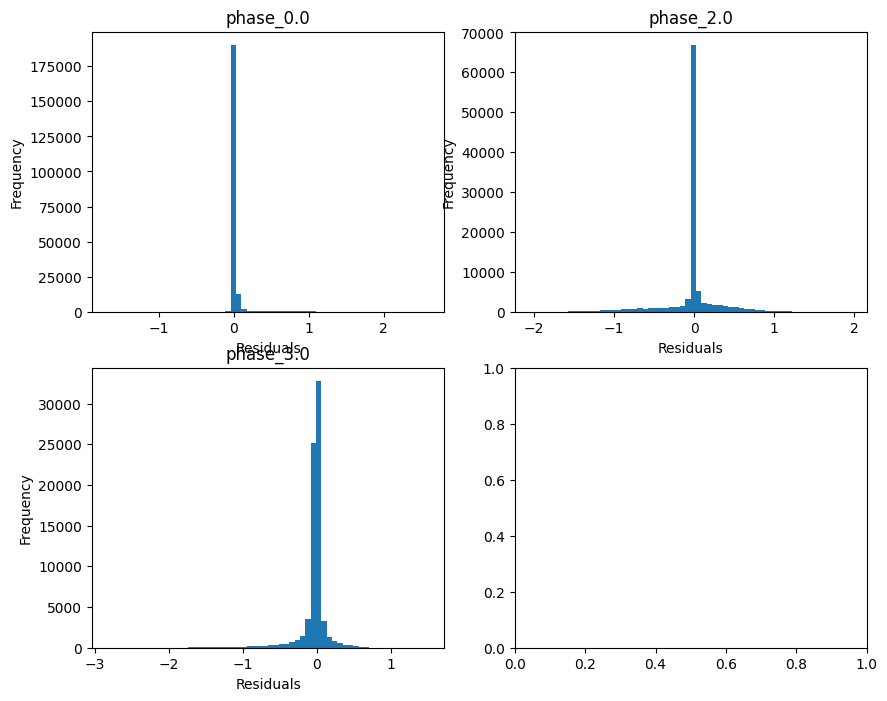

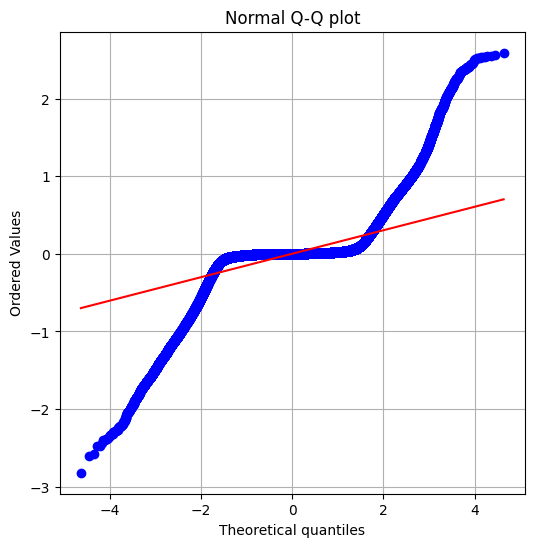

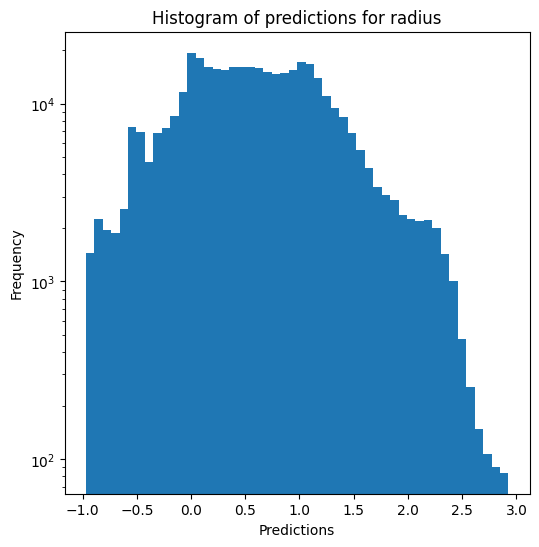

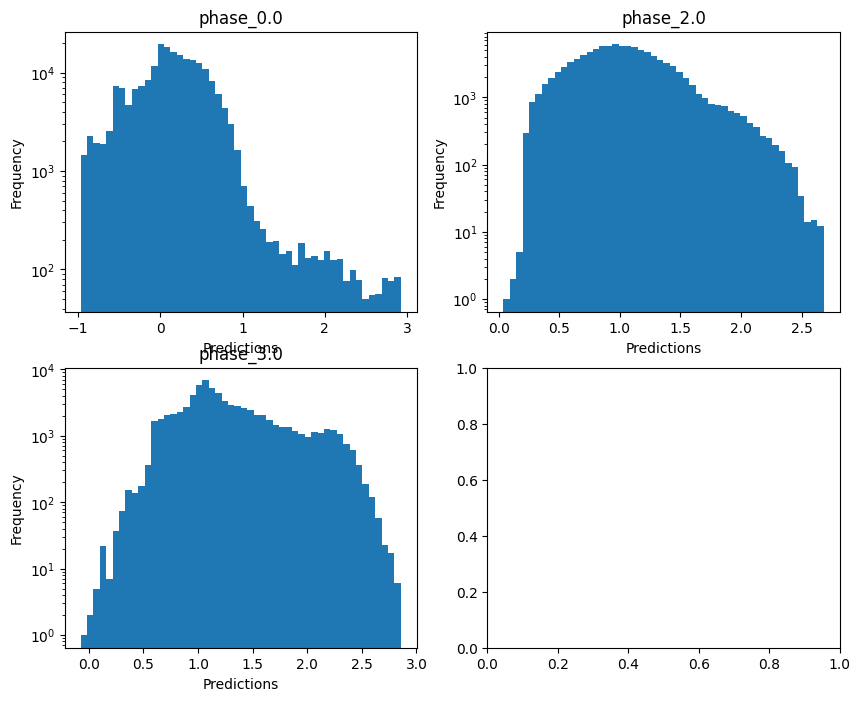

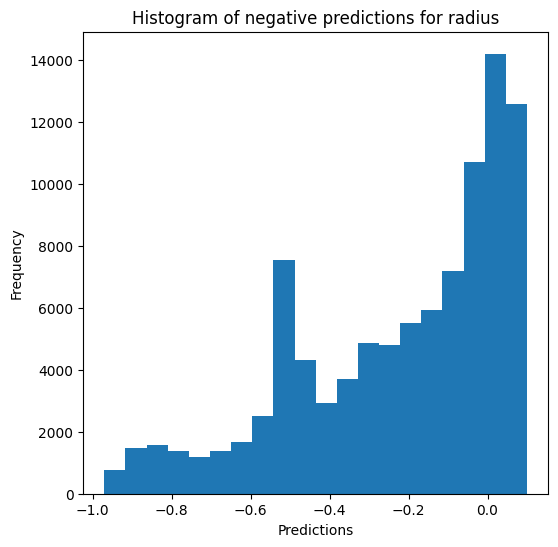

Saving predictions and results...


In [14]:
best_params_RF = {'n_jobs':10, 'n_estimators': 500, 'criterion': 'friedman_mse', 'max_depth': 100, 'min_samples_leaf': 5, 'min_samples_split': 6, 'max_features': 'sqrt', 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="quantile", **best_params_RF)

### K nearest neighbours

In [15]:
tag = "scale_quantile_14"

#### Testing the uniform weights with brute strength

In [16]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_knn = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn.fit(X_train, y_train)
display_grid_search(gscv_knn)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.3s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   3.9s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.011351,0.002772,4.183416,0.751492,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-0.244632,-0.242055,-0.241282,-0.238812,-0.244385,-0.235491,-0.236806,-0.238099,-0.241449,-0.245210,-0.240822,0.003234,2,-0.074984,-0.074383,-0.074031,-0.073601,-0.073715,-0.072639,-0.072172,-0.071942,-0.074601,-0.075692,-0.073776,0.001162,1
1,0.010580,0.001385,3.947181,0.039518,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-0.236755,-0.235810,-0.235730,-0.234154,-0.239337,-0.230162,-0.232440,-0.231771,-0.237097,-0.240774,-0.235403,0.003167,1,-0.080401,-0.080439,-0.080217,-0.079933,-0.080026,-0.078602,-0.078761,-0.078180,-0.081131,-0.082143,-0.079983,0.001144,2
2,0.010446,0.001424,3.985586,0.046978,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-0.248247,-0.248478,-0.247797,-0.247551,-0.250564,-0.242300,-0.245102,-0.243541,-0.248267,-0.253899,-0.247575,0.003177,3,-0.096262,-0.096492,-0.096394,-0.096206,-0.095556,-0.094575,-0.094740,-0.094388,-0.096870,-0.098500,-0.095998,0.001180,3
3,0.011205,0.001190,3.981108,0.030344,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-0.263250,-0.263869,-0.262968,-0.264281,-0.264923,-0.258263,-0.259593,-0.259252,-0.261869,-0.268813,-0.262708,0.002974,4,-0.113126,-0.113091,-0.113057,-0.113371,-0.111851,-0.111513,-0.111658,-0.111571,-0.113220,-0.115206,-0.112767,0.001091,4
4,0.010916,0.002381,4.058782,0.034491,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-0.289006,-0.290295,-0.288745,-0.291916,-0.290605,-0.285717,-0.287059,-0.286133,-0.288037,-0.293962,-0.289148,0.002468,5,-0.141720,-0.141954,-0.141782,-0.142474,-0.140768,-0.140787,-0.141352,-0.140549,-0.142591,-0.143806,-0.141778,0.000948,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 10, 'weights': 'uniform'}
Best score -0.23540305363743216


#### Testing the uniform weights with algorithms

In [17]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_knn = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn.fit(X_train, y_train)
display_grid_search(gscv_knn)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.238035,0.028161,0.939014,0.080670,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.244633,-0.242048,-0.241281,-0.238813,-0.244381,-0.235490,-0.236805,-0.238096,-0.241447,-0.245211,-0.240821,0.003234,11,-0.074982,-0.074370,-0.074026,-0.073594,-0.073702,-0.072629,-0.072165,-0.071928,-0.074590,-0.075690,-0.073768,0.001165,1
1,0.235271,0.025181,1.077552,0.035029,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.236755,-0.235811,-0.235728,-0.234154,-0.239336,-0.230169,-0.232440,-0.231770,-0.237097,-0.240774,-0.235404,0.003166,1,-0.080398,-0.080436,-0.080213,-0.079930,-0.080019,-0.078600,-0.078757,-0.078172,-0.081128,-0.082140,-0.079979,0.001144,11
2,0.226369,0.020136,1.231648,0.052541,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.248247,-0.248478,-0.247797,-0.247552,-0.250564,-0.242304,-0.245102,-0.243541,-0.248267,-0.253899,-0.247575,0.003176,29,-0.096262,-0.096491,-0.096393,-0.096206,-0.095554,-0.094576,-0.094740,-0.094386,-0.096869,-0.098498,-0.095997,0.001180,29
3,0.221424,0.022030,1.317714,0.071807,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.263250,-0.263869,-0.262968,-0.264281,-0.264923,-0.258263,-0.259593,-0.259252,-0.261869,-0.268813,-0.262708,0.002974,38,-0.113126,-0.113091,-0.113057,-0.113371,-0.111851,-0.111513,-0.111659,-0.111571,-0.113220,-0.115206,-0.112767,0.001091,40
4,0.230271,0.031560,1.600389,0.076679,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.289006,-0.290295,-0.288745,-0.291916,-0.290605,-0.285717,-0.287060,-0.286133,-0.288038,-0.293962,-0.289148,0.002468,41,-0.141720,-0.141954,-0.141782,-0.142474,-0.140768,-0.140787,-0.141352,-0.140549,-0.142591,-0.143806,-0.141778,0.000948,41
5,0.202588,0.013955,1.095819,0.050519,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.244633,-0.242048,-0.241281,-0.238813,-0.244381,-0.235490,-0.236805,-0.238096,-0.241447,-0.245211,-0.240821,0.003234,11,-0.074982,-0.074370,-0.074026,-0.073594,-0.073702,-0.072629,-0.072165,-0.071928,-0.074590,-0.075690,-0.073768,0.001165,1
6,0.197496,0.007523,1.240196,0.063107,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.236755,-0.235811,-0.235728,-0.234154,-0.239336,-0.230169,-0.232440,-0.231770,-0.237097,-0.240774,-0.235404,0.003166,1,-0.080398,-0.080436,-0.080213,-0.079930,-0.080019,-0.078600,-0.078757,-0.078172,-0.081128,-0.082140,-0.079979,0.001144,11
7,0.185384,0.004419,1.428661,0.074050,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.248247,-0.248478,-0.247797,-0.247552,-0.250564,-0.242304,-0.245102,-0.243541,-0.248267,-0.253899,-0.247575,0.003176,21,-0.096262,-0.096491,-0.096393,-0.096206,-0.095554,-0.094576,-0.094740,-0.094386,-0.096869,-0.098498,-0.095997,0.001180,23
8,0.185890,0.007598,1.488577,0.061411,

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}
Best score -0.23540354516948064


the algorithms give almost the same results then brute force with much less time. It is better to use them with distance calculation

#### Testing the distance weights with algorithms

In [18]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_knn_1 = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn_1.fit(X_train, y_train)
display_grid_search(gscv_knn_1)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.8s
[CV] END a

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.268756,0.049724,0.741650,0.075103,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.285492,-0.282795,-0.283035,-0.280180,-0.284098,-0.277600,-0.276386,-0.276858,-0.285041,-0.287944,-0.281943,0.003788,49,-0.084478,-0.083532,-0.083433,-0.082911,-0.083050,-0.081923,-0.081208,-0.080583,-0.084284,-0.085640,-0.083104,0.001462,1
1,0.440927,0.040754,1.346189,0.069082,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.285665,-0.282972,-0.283203,-0.280352,-0.284359,-0.277807,-0.276536,-0.277243,-0.285114,-0.288122,-0.282137,0.003757,55,-0.084712,-0.083750,-0.083663,-0.083116,-0.083250,-0.082187,-0.081386,-0.080860,-0.084437,-0.085827,-0.083319,0.001445,7
2,0.447713,0.035889,1.522287,0.100292,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.285912,-0.283226,-0.283341,-0.280419,-0.284420,-0.278044,-0.276748,-0.277362,-0.285047,-0.288380,-0.282290,0.003753,61,-0.084877,-0.083943,-0.083816,-0.083227,-0.083366,-0.082340,-0.081541,-0.081006,-0.084499,-0.085991,-0.083461,0.001445,13
3,0.225409,0.009113,0.988284,0.037407,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.286017,-0.283534,-0.283409,-0.280490,-0.284704,-0.278211,-0.277166,-0.277576,-0.285207,-0.288523,-0.282484,0.003713,67,-0.085023,-0.084132,-0.083903,-0.083326,-0.083499,-0.082473,-0.081684,-0.081149,-0.084618,-0.086103,-0.083591,0.001440,19
4,0.232644,0.013870,1.161847,0.079015,ball_tree,15,25,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.272311,-0.270839,-0.271791,-0.269403,-0.273476,-0.266385,-0.266837,-0.265208,-0.273039,-0.278297,-0.270759,0.003742,2,-0.096075,-0.095819,-0.095810,-0.095441,-0.095360,-0.093881,-0.093868,-0.093048,-0.096182,-0.098445,-0.095393,0.001445,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.211454,0.007315,0.410641,0.054310,kd_tree,100,25,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.274302,-0.273539,-0.274033,-0.271743,-0.275778,-0.268551,-0.268963,-0.267523,-0.274746,-0.280157,-0.272934,0.003642,22,-0.097283,-0.097237,-0.096982,-0.096636,-0.096490,-0.094984,-0.094969,-0.094221,-0.097235,-0.099478,-0.096551,0.001436,44
68,0.223058,0.022574,0.646002,0.115460,kd_tree,100,50,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.277453,-0.276697,-0.277526,-0.276699,-0.279057,-0.273228,-0.272828,-0.271919,-0.277904,-0.284328,-0.276764,0.003410,29,-0.109589,-0.110107,-0.109757,-0.109963,-0.109346,-0.108166,-0.108103,-0.107728,-0.110270,-0.112701,-0.109573,0.001354,53
69,0.226255,0.020044,0.898295,0.050983,kd_tree,100,50,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.278882,-0.278224,-0.278916,-0.278207,-0.280529,-0.274591,-0.274351,-0.273292,-0.2790

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 50, 'n_neighbors': 25, 'p': 1.0, 'weights': 'distance'}
Best score -0.2707586322329195


In [19]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : [gaussian],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100]
            }

gscv_knn_2 = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn_2.fit(X_train, y_train)
display_grid_search(gscv_knn_2)

Fitting 10 folds for each of 18 candidates, totalling 180 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001B754915260>; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001B754915260>; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001B754915260>; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001B754915260>; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001B754915260>; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001B754915260>; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001B754915260>; total time=   1.1s
[CV] END algorithm=ball_tree, leaf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.228947,0.010203,1.037003,0.054477,ball_tree,15,5,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.244623,-0.242036,-0.241274,-0.238806,-0.244371,-0.235484,-0.236793,-0.238091,-0.241443,-0.245200,-0.240812,0.003233,1,-0.074974,-0.074362,-0.074020,-0.073588,-0.073695,-0.072623,-0.072158,-0.071921,-0.074584,-0.075682,-0.073761,0.001164,1
1,0.227698,0.016938,1.482597,0.056641,ball_tree,15,25,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.255785,-0.256422,-0.255371,-0.255734,-0.257634,-0.249867,-0.252237,-0.251007,-0.254696,-0.261318,-0.255007,0.003165,7,-0.104740,-0.104731,-0.104745,-0.104655,-0.103594,-0.102934,-0.103007,-0.102800,-0.104899,-0.106841,-0.104295,0.001175,9
2,0.230414,0.051172,1.799813,0.052718,ball_tree,15,50,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.288663,-0.289961,-0.288417,-0.291583,-0.290254,-0.285398,-0.286688,-0.285760,-0.287695,-0.293633,-0.288805,0.002475,13,-0.141514,-0.141751,-0.141580,-0.142268,-0.140557,-0.140583,-0.141133,-0.140330,-0.142380,-0.143602,-0.141570,0.000951,13
3,0.194495,0.028295,1.627281,0.139633,ball_tree,50,5,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.244623,-0.242036,-0.241274,-0.238806,-0.244371,-0.235484,-0.236793,-0.238091,-0.241443,-0.245200,-0.240812,0.003233,1,-0.074974,-0.074362,-0.074020,-0.073588,-0.073695,-0.072623,-0.072158,-0.071921,-0.074584,-0.075682,-0.073761,0.001164,1
4,0.184132,0.007458,2.146620,0.160381,ball_tree,50,25,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.255785,-0.256422,-0.255371,-0.255734,-0.257634,-0.249867,-0.252237,-0.251007,-0.254696,-0.261318,-0.255007,0.003165,11,-0.104740,-0.104731,-0.104745,-0.104655,-0.103594,-0.102934,-0.103007,-0.102800,-0.104899,-0.106841,-0.104295,0.001175,12
5,0.187999,0.010458,2.403459,0.191652,ball_tree,50,50,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.288663,-0.289961,-0.288417,-0.291583,-0.290254,-0.285398,-0.286688,-0.285760,-0.287695,-0.293633,-0.288805,0.002475,17,-0.141514,-0.141751,-0.141580,-0.142268,-0.140557,-0.140583,-0.141133,-0.140330,-0.142380,-0.143602,-0.141570,0.000951,17
6,0.166329,0.006375,1.952905,0.113737,ball_tree,100,5,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.244623,-0.242036,-0.241274,-0.238806,-0.244371,-0.235484,-0.236793,-0.238091,-0.241443,-0.245200,-0.240812,0.003233,1,-0.074974,-0.074362,-0.074020,-0.073588,-0.073695,-0.072623,-0.072158,-0.071921,-0.074584,-0.075682,-0.073761,0.001164,1
7,0.168169,0.008038,2.747613,0.343006,ball_tree,100,25,<function gaussian at 0x000001B754915260>,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.255785,-0.

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': <function gaussian at 0x000001B754915260>}
Best score -0.240812095792745


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_B/fine_tuned_models/

scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.344668191350628 - 4.634489491902143
  RVE :  0.9859595952115086
  RMSE :  0.035443435325520155
  MAE :  0.006309935646251374
  MedAE :  0.0013124591260904594
  CORR :  0.9930119554347848
  MAX_ER :  0.8750465956130271
  Percentiles : 
    75th percentile :  0.002875309959433636
    90th percentile :  0.006300448045762153
    95th percentile :  0.010942061443095053
    99th percentile :  0.11348074074804751

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.5876557299556575
  RVE :  0.9758527600432764
  RMSE :  0.038174903290954784
  MAE :  0.01860810063901525
  MedAE :  0.0047416498316723565
  CORR :  0.9878912658322937
  MAX_ER :  0.5909715941533982
  Percentiles : 
    75th percentile : 

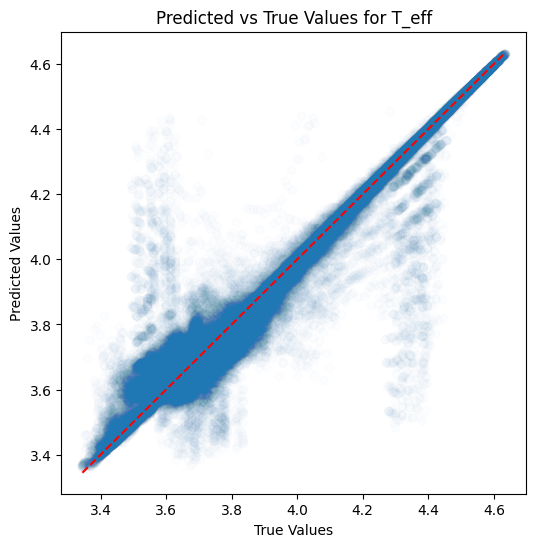

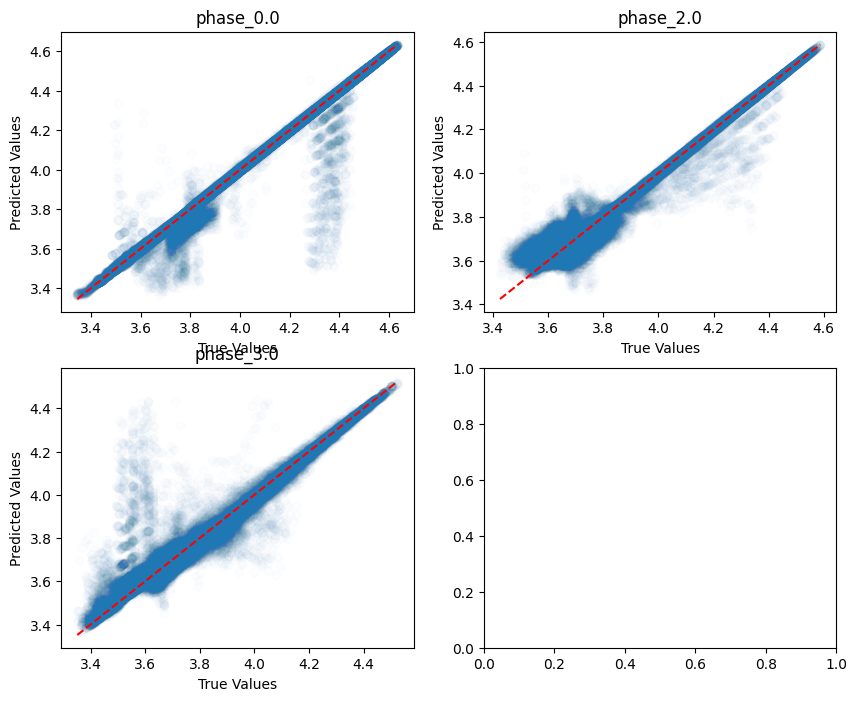

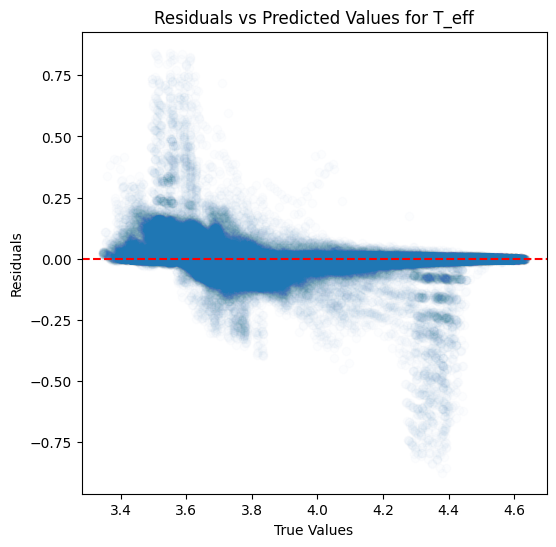

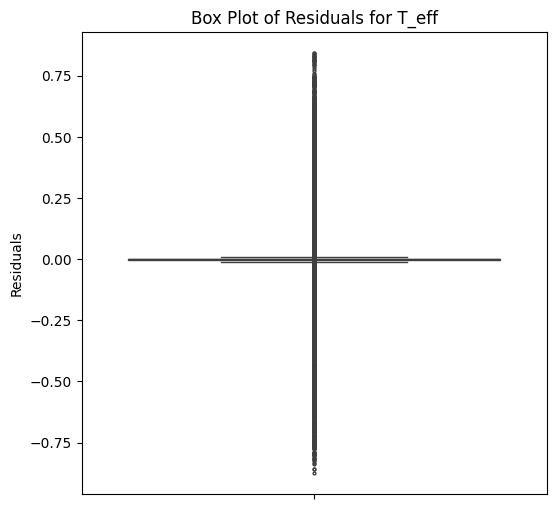

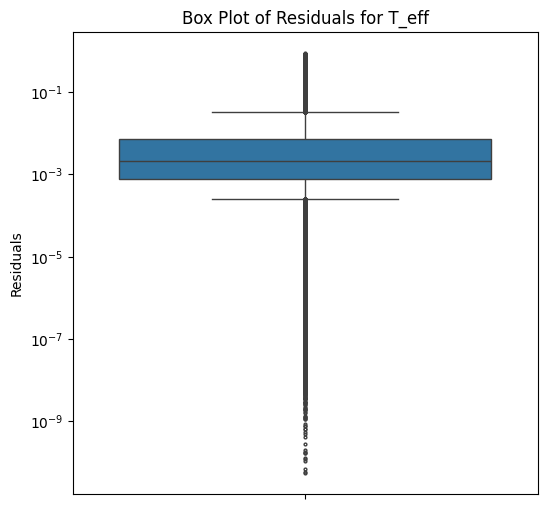

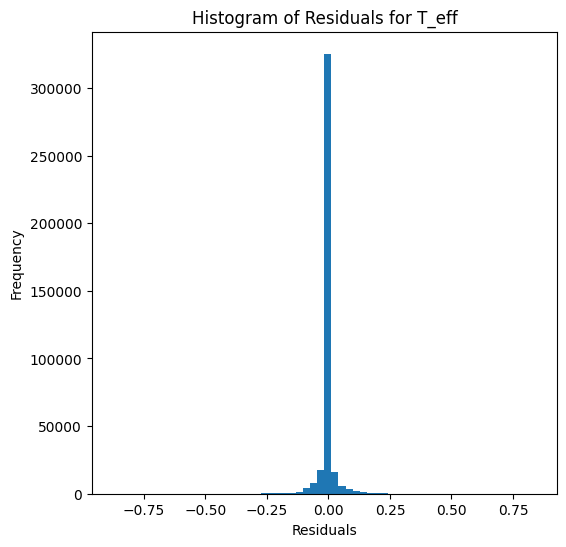

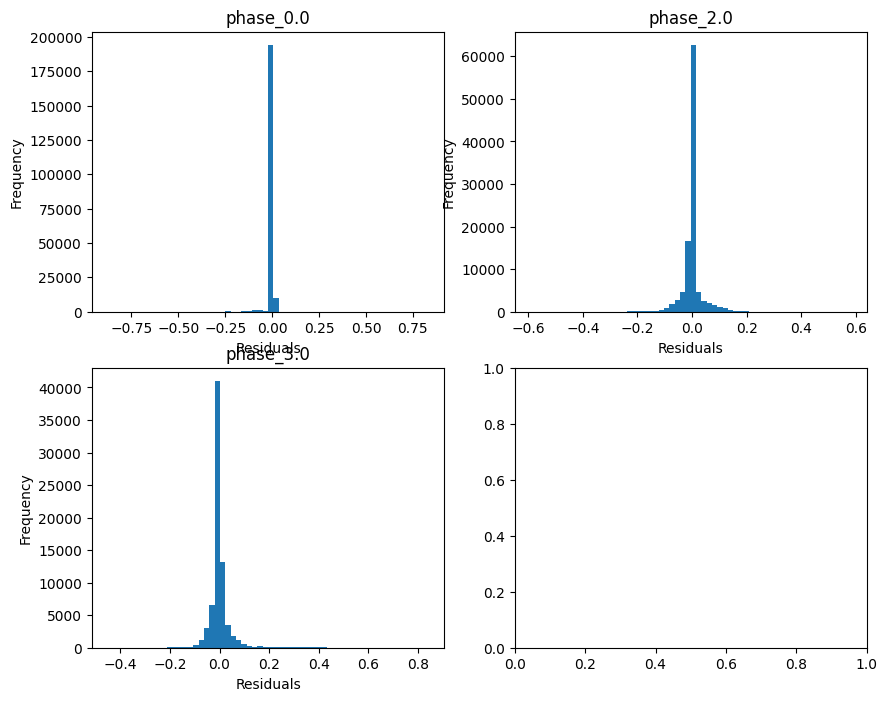

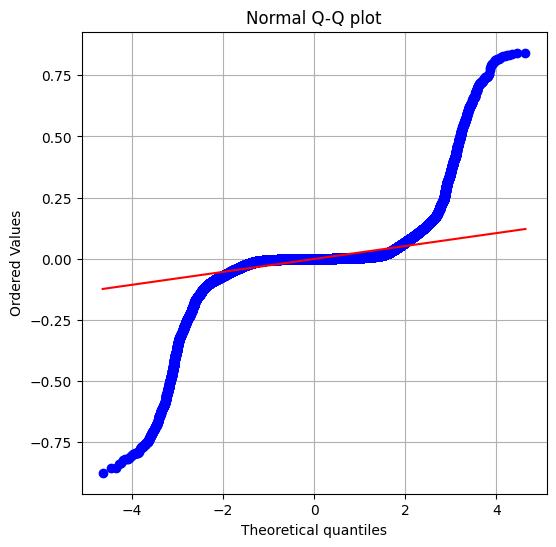

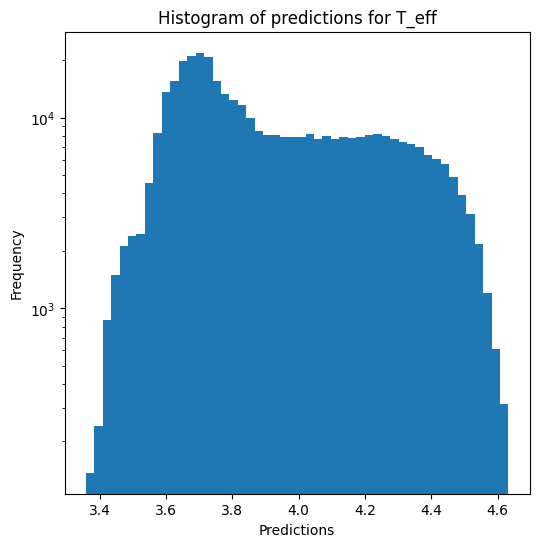

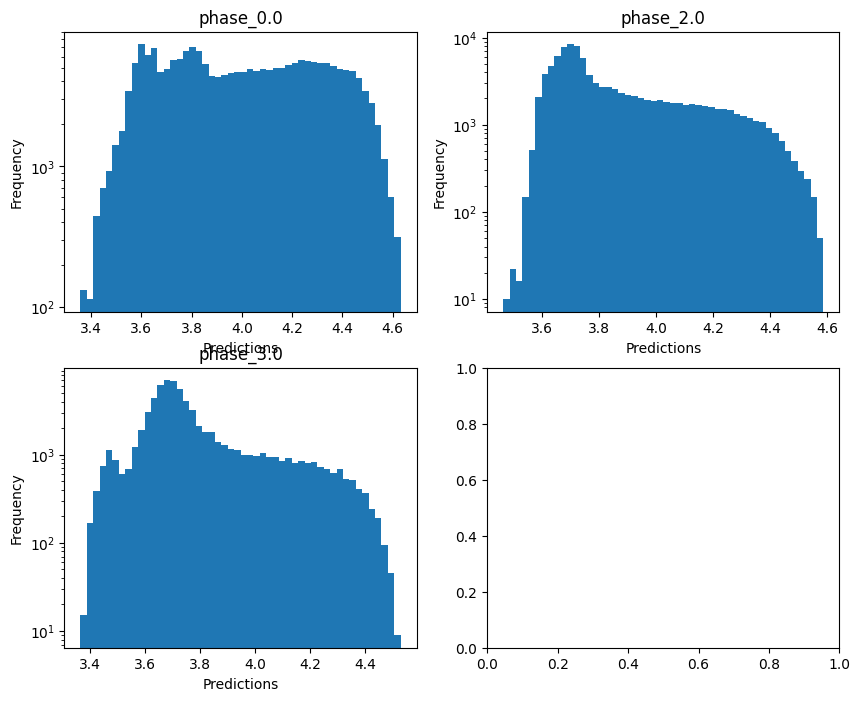


log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.5175643182237635
  RMSE :  0.31980365766823304
  MAE :  0.05309782064736759
  MedAE :  0.003212317608762838
  CORR :  0.8350238559415276
  MAX_ER :  5.493119497182191
  Percentiles : 
    75th percentile :  0.00974498167167237
    90th percentile :  0.022216890095571352
    95th percentile :  0.03745082411147405
    99th percentile :  1.708560555485141

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.4079093481651865
  RVE :  0.5894724044401471
  RMSE :  0.5946731095552794
  MAE :  0.28571818977054886
  MedAE :  0.02391769195926674
  CORR :  0.7694181811132952
  MAX_ER :  3.9464210686036396
  Percentiles : 
    75th percentile :  0.31819316117561114
    90th percentile :  1.0721570907233446
    95th percentile :  1.4903134616779734
    99th percentile :  2.2226478113419406

log_g results for the phase category wi

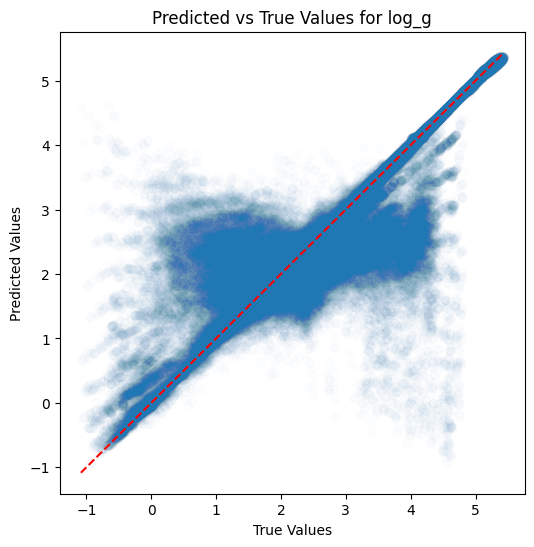

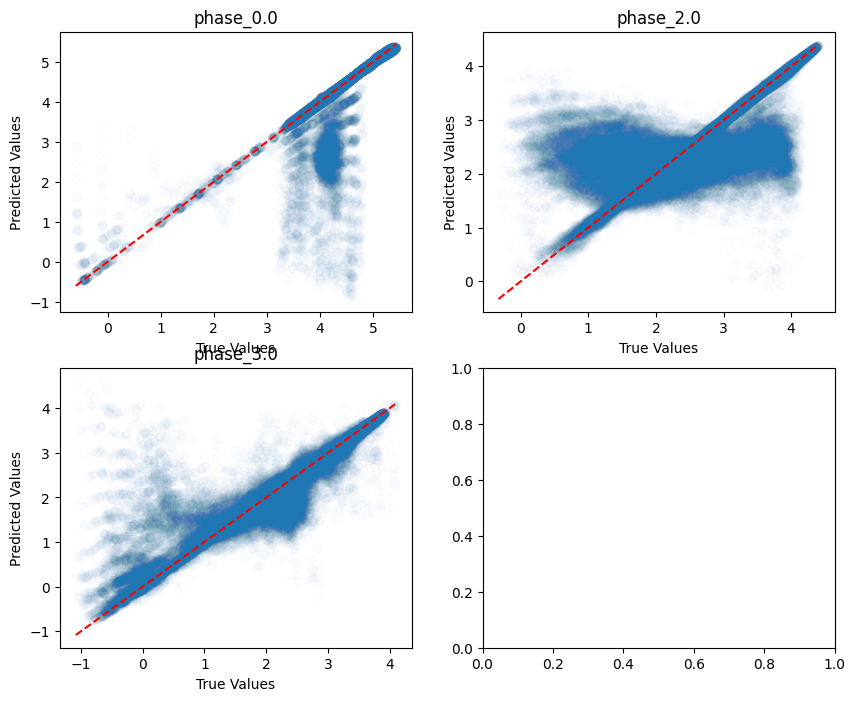

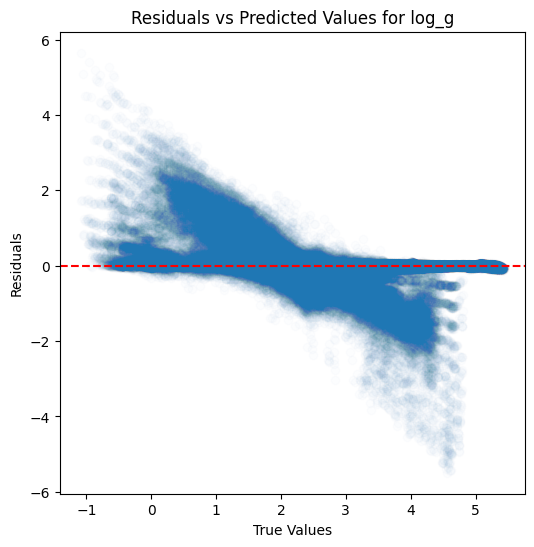

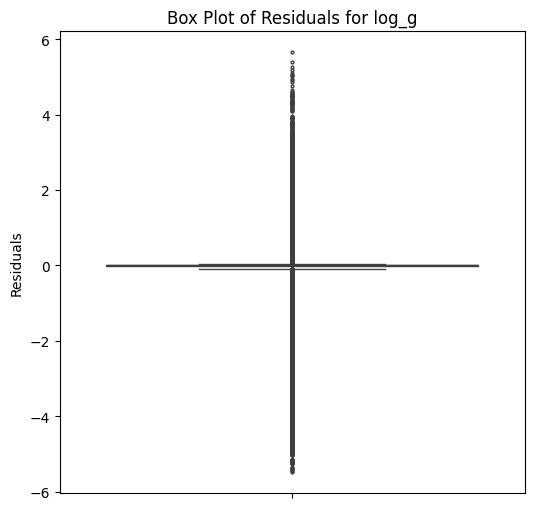

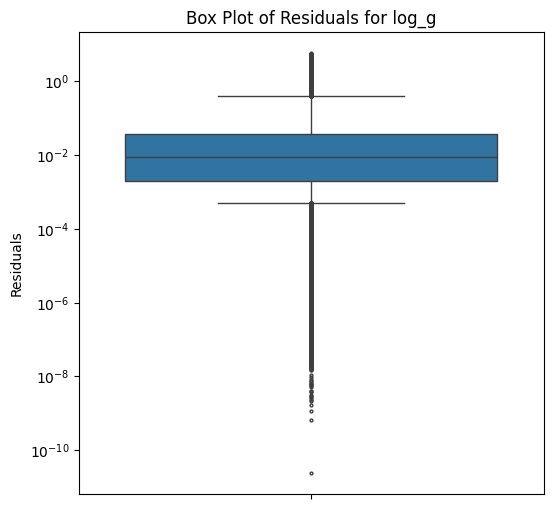

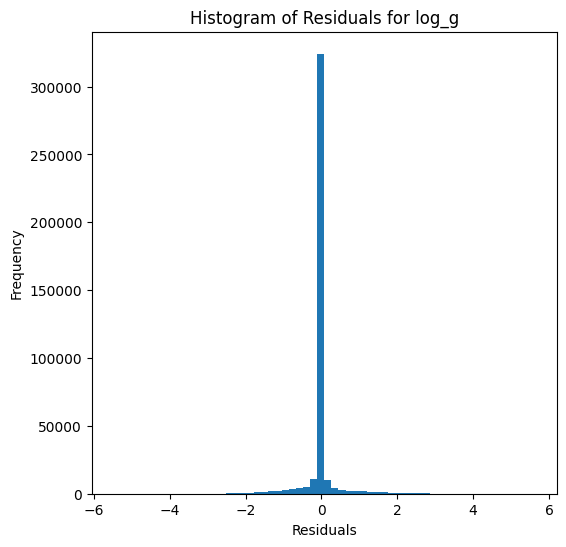

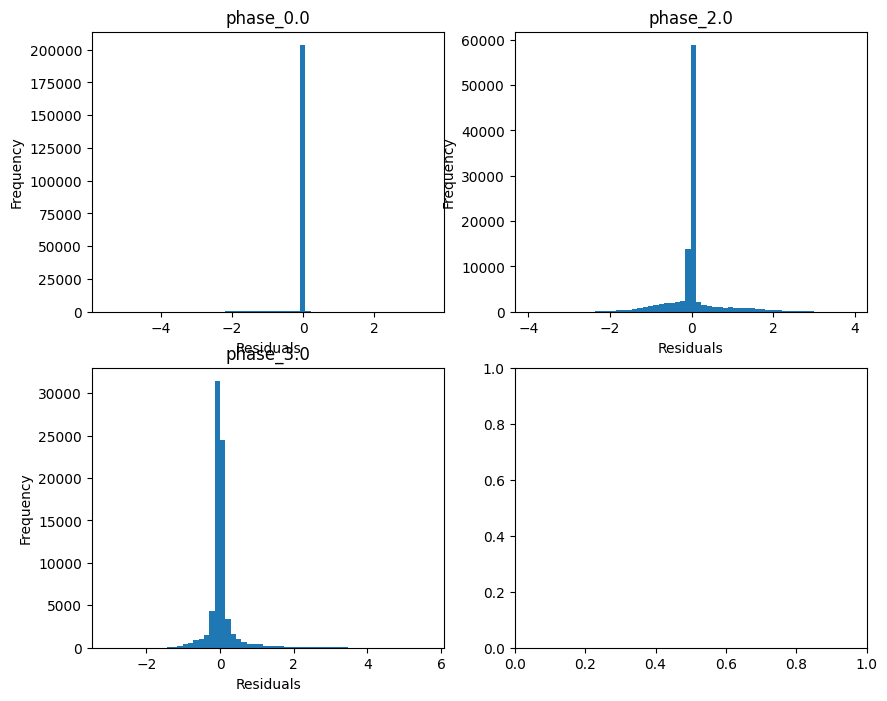

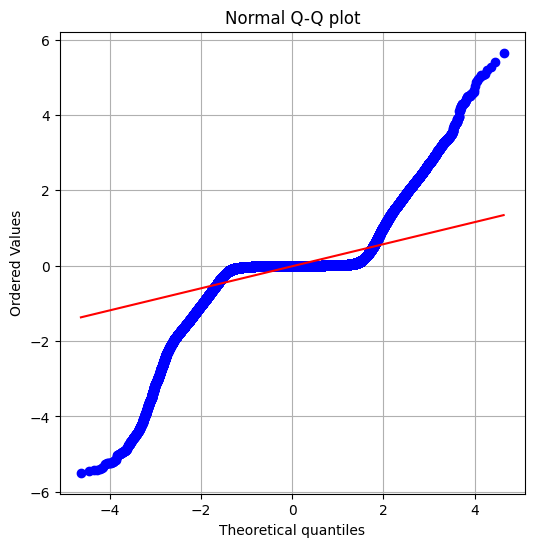

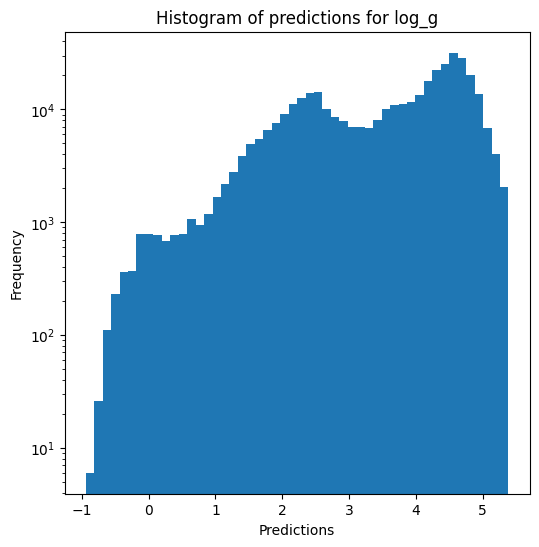

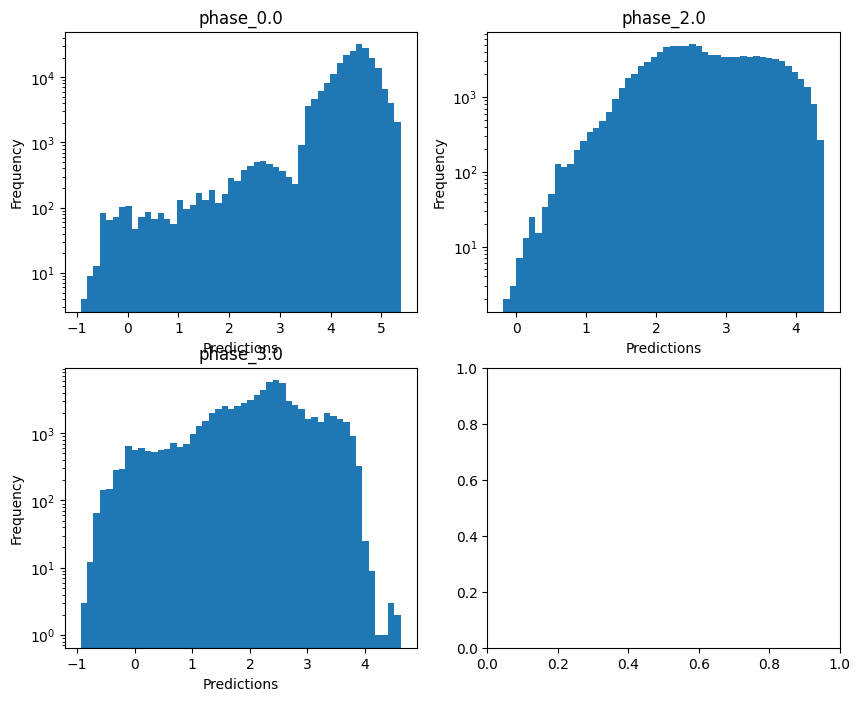

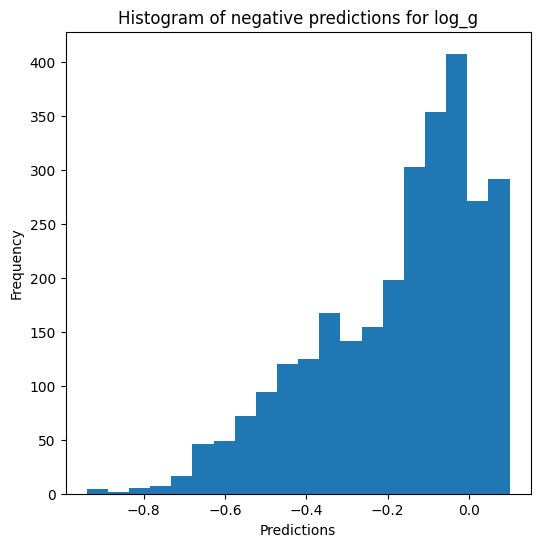


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.8584362454016706
  RMSE :  0.16012467646438003
  MAE :  0.028396125035843555
  MedAE :  0.002618463769862911
  CORR :  0.9366479192485917
  MAX_ER :  2.747271008971443
  Percentiles : 
    75th percentile :  0.006928889568791341
    90th percentile :  0.015398268675915006
    95th percentile :  0.030550467133876682
    99th percentile :  0.8542789847207227

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.59207641797828
  RMSE :  0.29733424024124727
  MAE :  0.14286977038043008
  MedAE :  0.011983625545423066
  CORR :  0.7729678594000104
  MAX_ER :  1.9732292768837336
  Percentiles : 
    75th percentile :  0.15910874444711876
    90th percentile :  0.5360521842700544
    95th percentile :  0.7453005314144068
    99th percentile :  1.1114477836632481

radius results for the phase categ

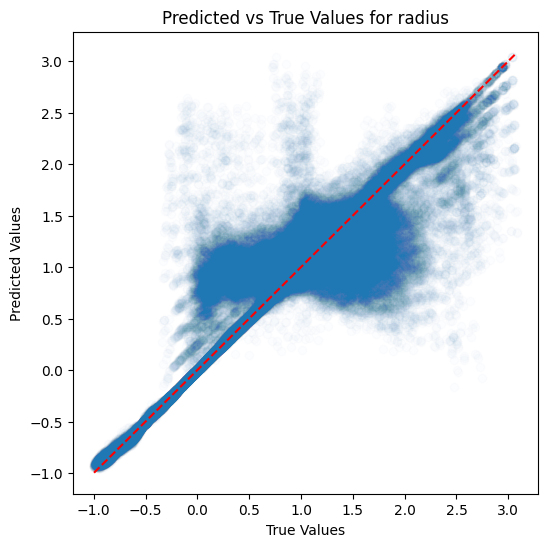

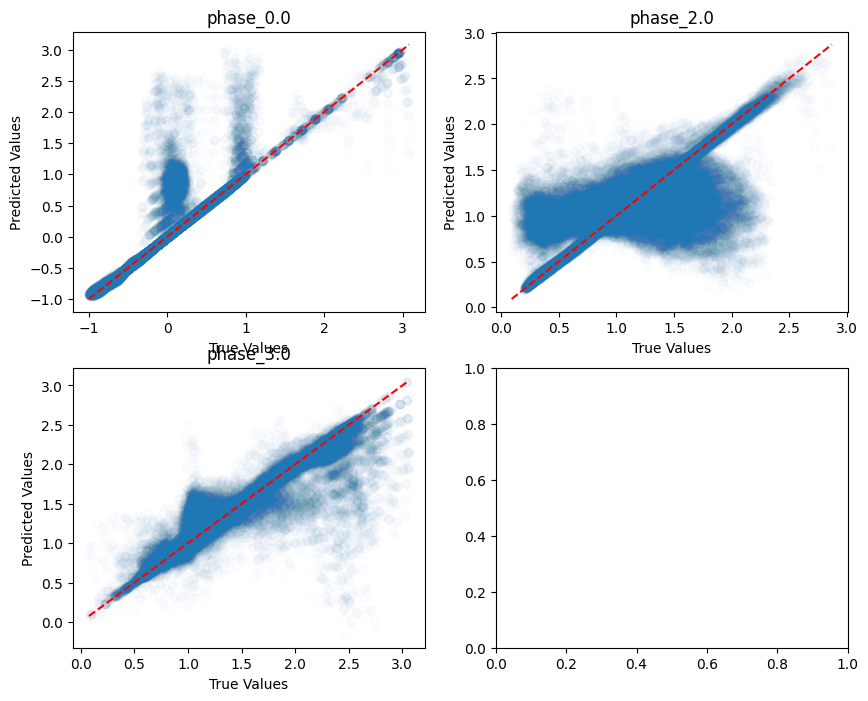

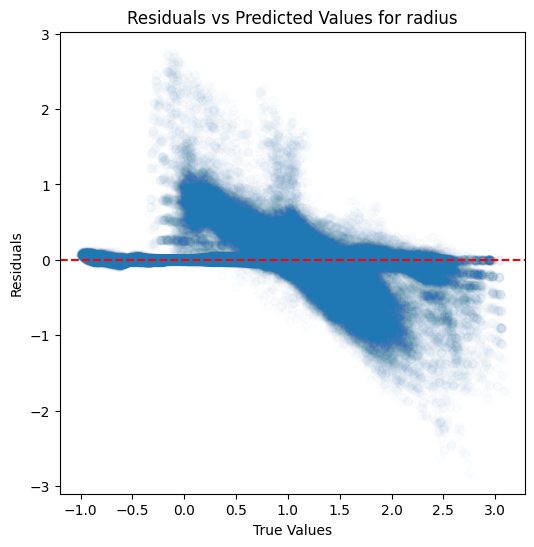

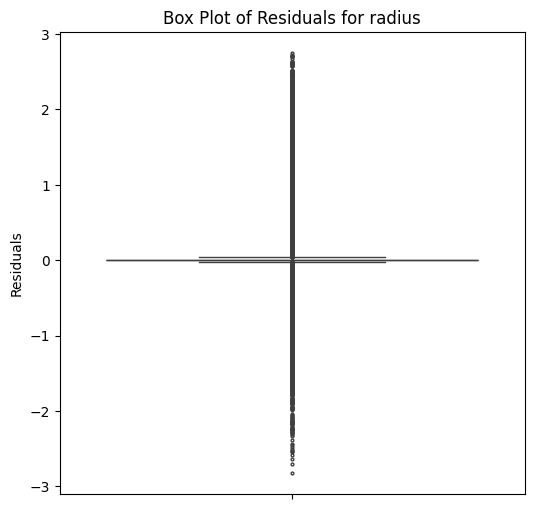

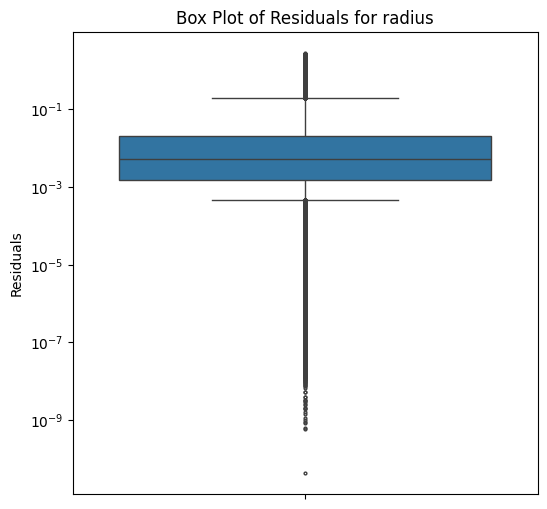

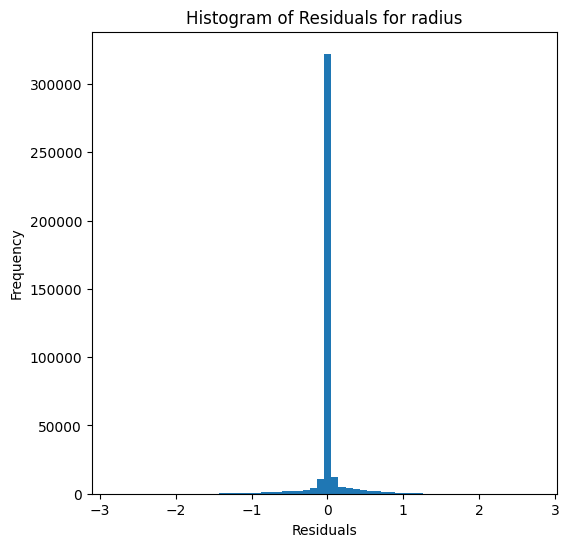

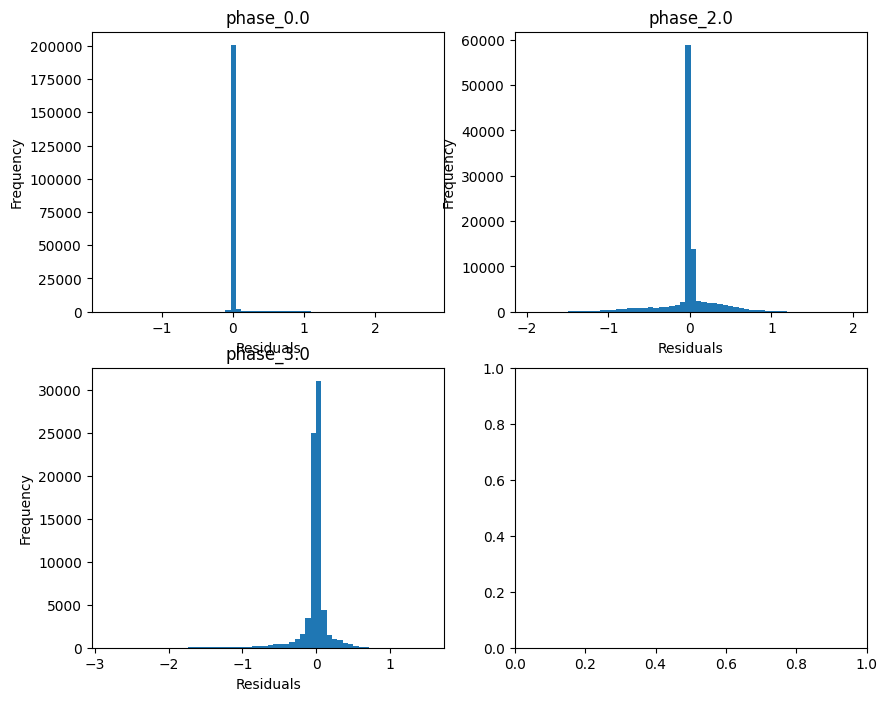

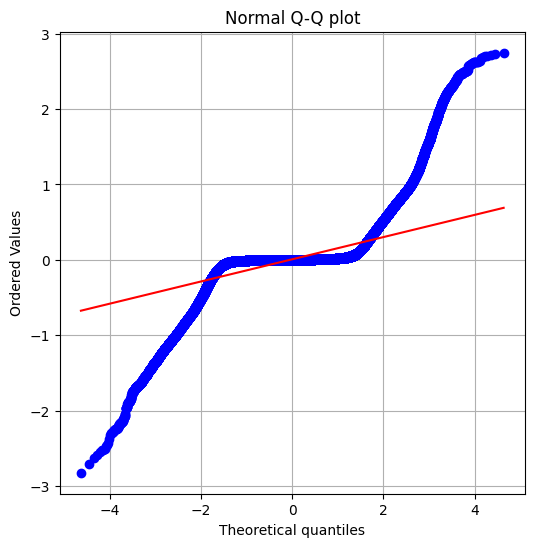

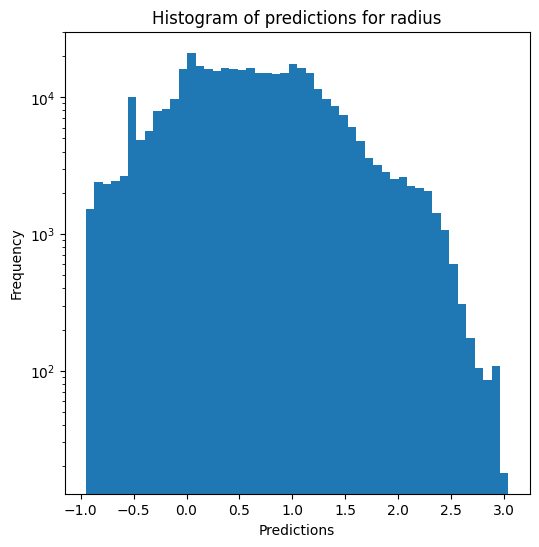

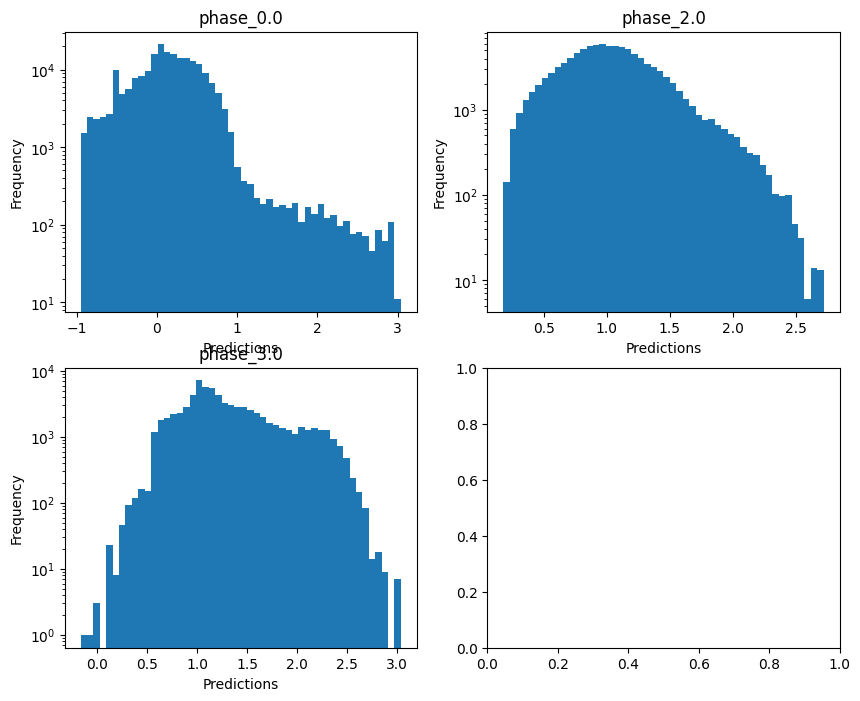

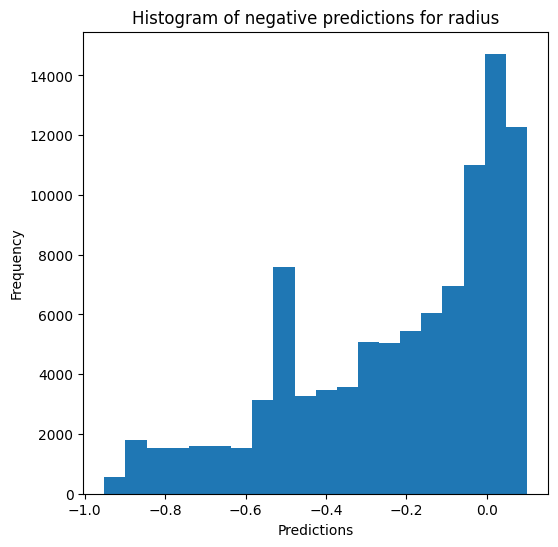

Saving predictions and results...


In [20]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

print(path_to_results)
dt_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="quantile", **best_params_KNN)